## Projekt EDA z uwzględnieniem czynnika przestrzennego
Jakub Niedźwiedź

Oliwier Kolbusz

Roksana Jandura

In [1]:
import pandas as pd
import itables as it
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import re
import unicodedata
from IPython.display import IFrame
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display


it.init_notebook_mode(all_interactive=True)

In [2]:
data = pd.read_excel('who_aap_2021_v9_11august2022.xlsx', sheet_name='AAP_2022_city_v9')
data

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Itables ułatwia przeglądanie tego typu danych. Można w łatwy sposób znaleźć np. sposób nazewnictwa krajów i regionów, sprawnie przeglądąć rekordy dzięki paginacji i sortować elementy.

### Braki danych

In [3]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Braki (ilość)': missing_data, 'Braki (%)': missing_percent})
missing_df

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Dane identyfikacyjne, takie jak kraj, miasto czy rok pomiaru nie posiadają braków danych. 

W przypadku PM2.5 ponad połowa danych (ok. 53%) jest brakująca, dla PM10 i NO2 braki są mniejsze, ale nadal istotne (około 34% i 31%).

Jeszcze większe braki występują w zmiennych dotyczących pokrycia czasowego pomiarów. Dla PM10 i PM2.5 temporal coverage braki są równe ok. 83% i 77% , co sugeruje, że w wielu przypadkach nie wiadomo, jak pełne są dane pomiarowe. W praktyce oznacza to ograniczoną możliwość oceny wiarygodności danych.

Podobnie wygląda sytuacja dla zmiennej „Number and type of monitoring stations”, gdzie brakuje ponad 70% danych.

In [4]:
data[data['WHO Region'].isnull()]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [5]:
data[data['WHO Country Name'] == 'Liechtenstein']

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [6]:
data['WHO Region'].unique()

array(['Eastern Mediterranean Region', 'European Region',
       'Region of the Americas', 'Western Pacific Region',
       'South East Asia Region', 'African Region', nan], dtype=object)

Brak wartości w kolumnie „WHO Region” występuje tylko dla jednego przypadku. Dla tego kraju dostępny jest tylko jeden rekord (rok 2010).
Na podstawie wiedzy geograficznej można stwierdzić, że Liechtenstein znajduje się w Europie, więc powinien należeć do regionu European Region. Oznacza to, że brak wartości w kolumnie „WHO Region” nie wynika z braku danych pomiarowych, lecz jest najprawdopodobniej błędem lub niedopatrzeniem w zbiorze danych. Dlatego zdecydowano się na uzupełnienie tej wartości.

In [7]:
data.loc[
    (data['WHO Country Name'] == 'Liechtenstein') & 
    (data['WHO Region'].isnull()),
    'WHO Region'
] = 'European Region'
data['WHO Region'].isnull().sum()

0

**Analiza braków danych w poszczególnych latach**

In [8]:
cols = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']
missing_by_year = data.groupby('Measurement Year')[cols].apply(lambda x: x.isnull().mean() * 100)

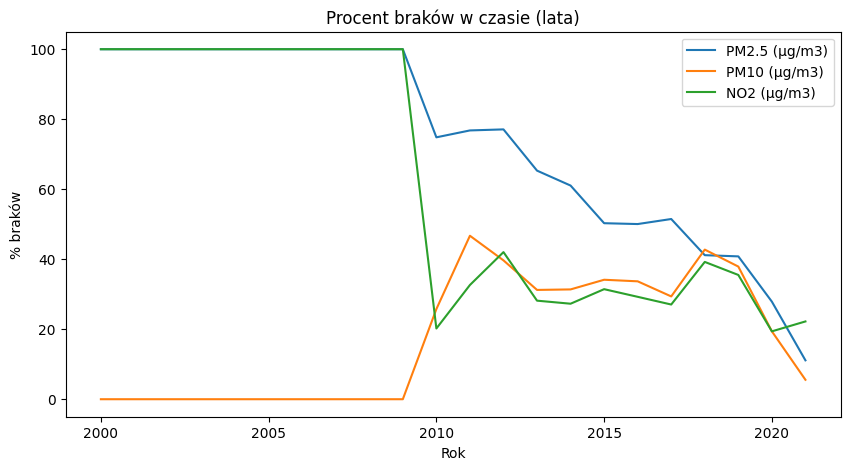

In [9]:
missing_by_year.plot(figsize=(10,5))
plt.title("Procent braków w czasie (lata)")
plt.ylabel("% braków")
plt.xlabel("Rok")
plt.show()

Na wykresie widać wyraźnie, że dostępność danych zmienia się w czasie. Do ok 2009 roku dane dla PM2.5 i NO2 są całkowicie niedostępne – braki na poziomie 100%. Oznacza to, że w tym okresie pomiary tych zanieczyszczeń nie były raportowane.

Po 2010 roku następuje wyraźna poprawa jakości danych. Procent braków dla PM2.5 i NO2 zaczyna spadać, co sugeruje rozwój systemów monitoringu oraz lepsze raportowanie danych przez kraje.

Największe braki przez cały analizowany okres dotyczą PM2.5, który pozostaje najmniej kompletną zmienną. Nawet w późniejszych latach udział braków jest wyższy niż dla PM10 i NO2. Może to wynikać z większej trudności pomiaru tego zanieczyszczenia lub późniejszego wprowadzenia jego monitoringu.

Dla PM10 do ok. 2009 roku nie wystąpiły żadne braki, a w późniejszych latach były na zbliżonym poziomie co dla zmiennej NO2.

Podsumowując, bardziej wiarygodne są dane z ostatnich lat, gdzie poziom braków jest niższy i bardziej stabilny. Wskazuje to, że rozwój systemów monitoringu powietrza w czasie ma istotny wpływ na jakość dostępnych danych.

**Zdecydowano się na analize braków na poziomie państw**

In [10]:
missing_by_country_percent = data.groupby('WHO Country Name')[cols].apply(lambda x: x.isnull().mean() * 100)
missing_by_country_percent.sort_values( by='PM2.5 (μg/m3)', ascending=False).reset_index()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Analiza braków danych dla PM2.5 na poziomie krajów pokazuje, że problem nie jest równomiernie rozłożony. W niektórych państwach braki są niemal całkowite. Przykładowo, dla takich krajów jak Montenegro i Mauritius brak danych wynosi 100%. Zróżnicowanie między krajami sugeruje, że problem braków danych ma charakter lokalny, a nie globalny. Najprawdopodobniej wynika to z różnic w dostępności infrastruktury pomiarowej, poziomie rozwoju systemów monitoringu środowiska oraz standardach raportowania danych.

Analiza braków danych dla PM10 pokazuje, że sytuacja jest podobna jak w przypadku PM2.5. W części państw, takich jak np. Fiji, Ethiopia, El Salvador, Cuba czy Algeria, braki danych wynoszą 100%.

Podobnie jak wcześniej, widoczne jest duże zróżnicowanie między krajami. Niektóre państwa mają pełne lub prawie pełne dane, podczas gdy inne nie posiadają ich w ogóle. Wskazuje to na nierównomierny rozwój systemów monitoringu jakości powietrza.

Analiza braków danych dla NO2 pokazuje, że w wielu krajach braki wynoszą 100%, co oznacza całkowity brak danych dla tego zanieczyszczenia.

**Zdecydowano się na analize braków na poziomie regionów**

In [11]:
missing_by_region_percent = data.groupby('WHO Region')[cols].apply(lambda x: x.isnull().mean() * 100)

In [12]:
missing_by_region_percent.reset_index()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Analiza braków danych na poziomie regionów została wykonana, ponieważ pozwala zobaczyć ogólne różnice przestrzenne, a nie tylko pojedyncze przypadki krajów. Redukuje „szum” danych – pojedyncze kraje z ekstremami nie zaburzają aż tak wyników.

W regionie Ameryk poziom braków dla wszystkich trzech analizowanych zanieczyszczeń jest zbliżony i wynosi około 42–46%. Oznacza to, że dane są w tym regionie umiarkowanie niekompletne, ale problem braków dotyczy wszystkich zmiennych w podobnym stopniu.

W regionie Zachodniego Pacyfiku sytuacja jest wyraźnie zróżnicowana. Dla PM2.5 poziom braków jest bardzo niski (około 7%), co wskazuje na dobrą dostępność danych. Natomiast dla PM10 i NO2 braki są bardzo wysokie (ponad 85%), co oznacza, że pomiary tych zanieczyszczeń są w tym regionie znacznie rzadziej dostępne lub całkowicie niedostępne w niektórych państwach.

W regionie Afrykańskim poziom braków jest stosunkowo niższy i bardziej wyrównany w porównaniu do innych regionów. Wartości dla PM2.5 i NO2 wynoszą około 34–35%, natomiast dla PM10 są jeszcze niższe (około 16%).

W regionie Europy największy problem z brakami występuje dla zmiennej PM2.5. Dla PM10 i NO2 braki są na poziomie 16-20%.

Kolumna 'Status' zawierała same wartości NaN, dlatego zdecydowano się ją całkowicie usunąć z analizy

In [13]:
data.drop(columns=['Status'], inplace=True)

### Informacje o danych dla zanieczyszczeń

In [14]:
pollutants = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']
display(data[pollutants].describe())

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Wartości maksymalne dla wszystkich zanieczyszczeń są bardzo wysokie, co wskazuje na obecność wartości odstających.

PM10 osiąga najwyższe max, co sugeruje największą zmienność i możliwe ekstremalne przypadki.

Rozkład danych jest prawostronnie skośny – większość obserwacji ma niższe wartości, a wysokie wartości występują rzadko.

**Analiza zanieczyszczeń w podziale na regiony**

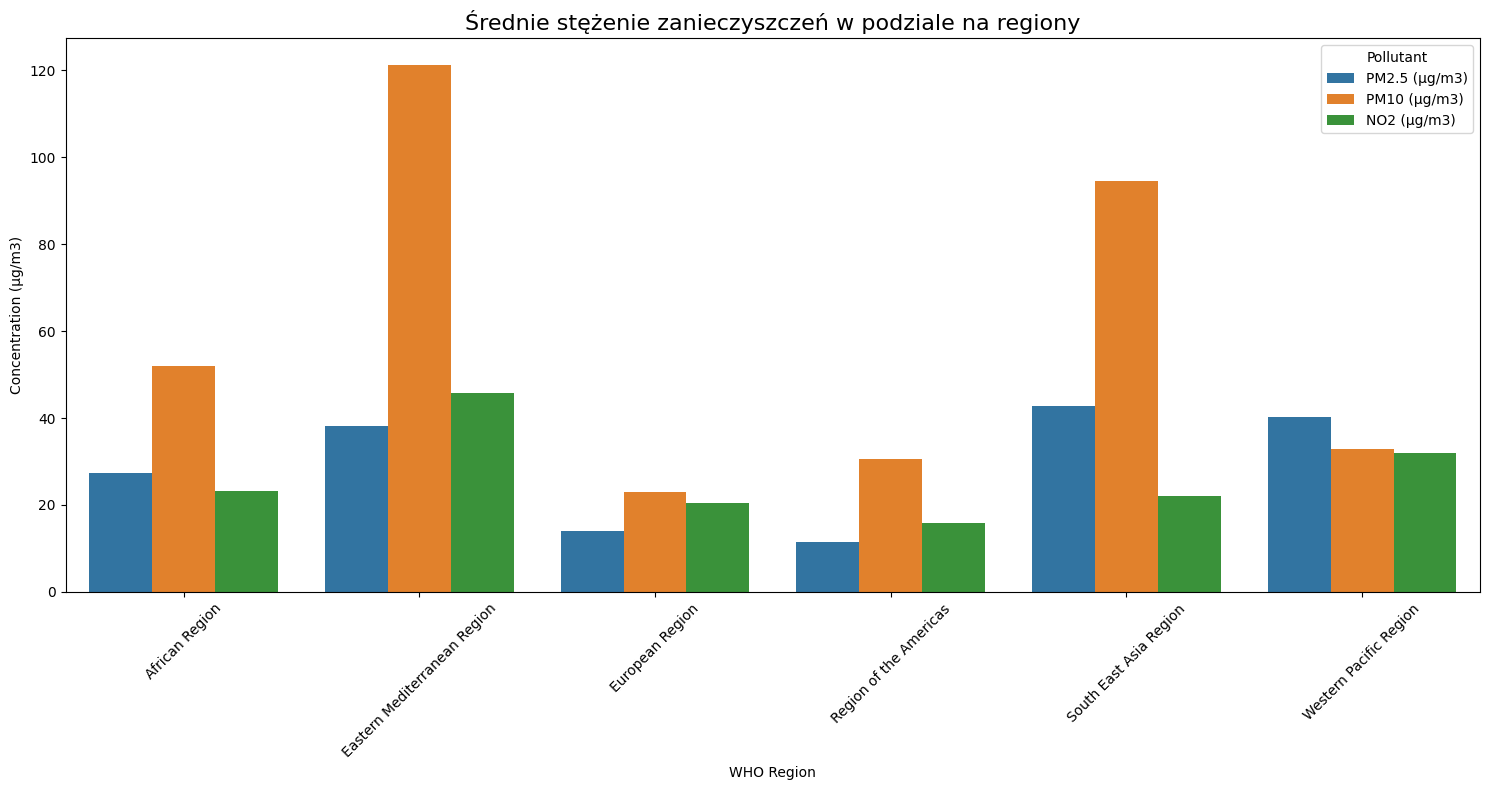

In [15]:
region_mean = data.groupby('WHO Region')[pollutants].mean().reset_index()

region_mean_melted = region_mean.melt(id_vars='WHO Region', var_name='Pollutant', value_name='Concentration (μg/m3)')

plt.figure(figsize=(15, 8))
sns.barplot(data=region_mean_melted, x='WHO Region', y='Concentration (μg/m3)', hue='Pollutant')
plt.title('Średnie stężenie zanieczyszczeń w podziale na regiony', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analiza średnich wartości zanieczyszczeń na poziomie regionów pozwala zidentyfikować globalne różnice w jakości powietrza i wskazać obszary o największym natężeniu problemu. 

Region Wschodniego Śródziemnomorza ma najwyższe średnie stężenia wszystkich zanieczyszczeń, szczególnie PM10, co wskazuje na bardzo wysokie zanieczyszczenie powietrza.

Region Azji również charakteryzuje się wysokimi wartościami, zwłaszcza dla PM10 i PM2.5, co sugeruje duże problemy z jakością powietrza.

Najniższe wartości występują w Europie i Regionie Ameryk, co wskazuje na lepszą jakość powietrza lub skuteczniejsze działania ograniczające emisję.

Region Zachodniego Pacyfiku ma wyniki zbliżone dla wszystkich tzrech wartości. 

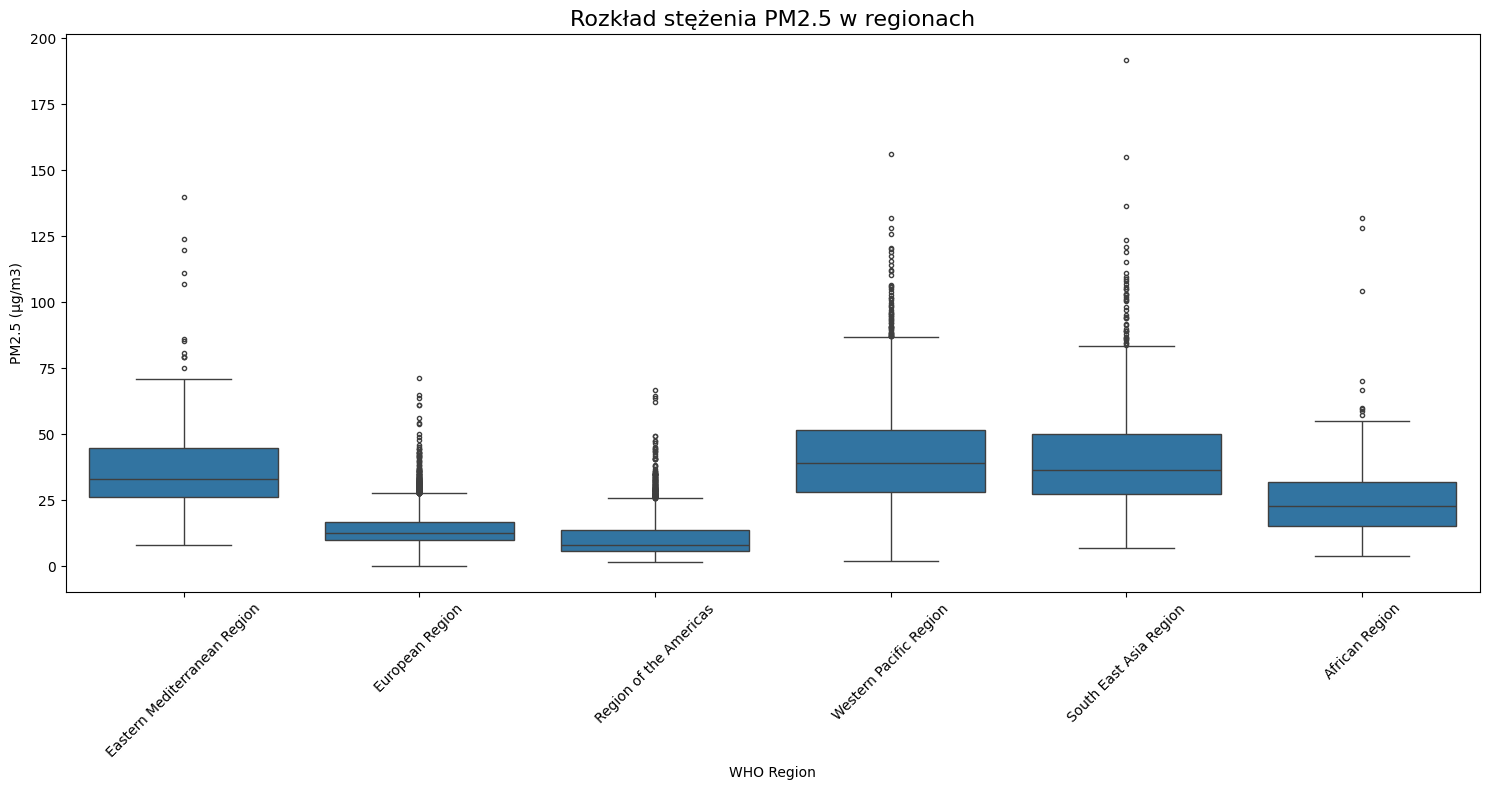

In [16]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=data, x='WHO Region', y='PM2.5 (μg/m3)', fliersize=3)
plt.title('Rozkład stężenia PM2.5 w regionach', fontsize=16)
plt.xticks(rotation=45)
plt.ylabel('PM2.5 (μg/m3)')
plt.tight_layout()
plt.show()

Rozkład wartości PM2.5 różni się między regionami, co widać po zakresach wąsów.

W niektórych regionach (Eastern Mediterranean, South-East Asia, Western Pacific) występuje duża zmienność danych – wartości są mocno rozproszone, co wskazuje na duże różnice między miastami.

Regiony takie jak Europa czy Ameryki mają bardziej skupione rozkłady, co oznacza bardziej stabilne i wyrównane poziomy PM2.5.

Widoczne są również wartości odstające (outliery), co potwierdza obecność ekstremalnych przypadków bardzo wysokiego zanieczyszczenia.

C:\Users\Dell\AppData\Local\Temp\ipykernel_12280\518478443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


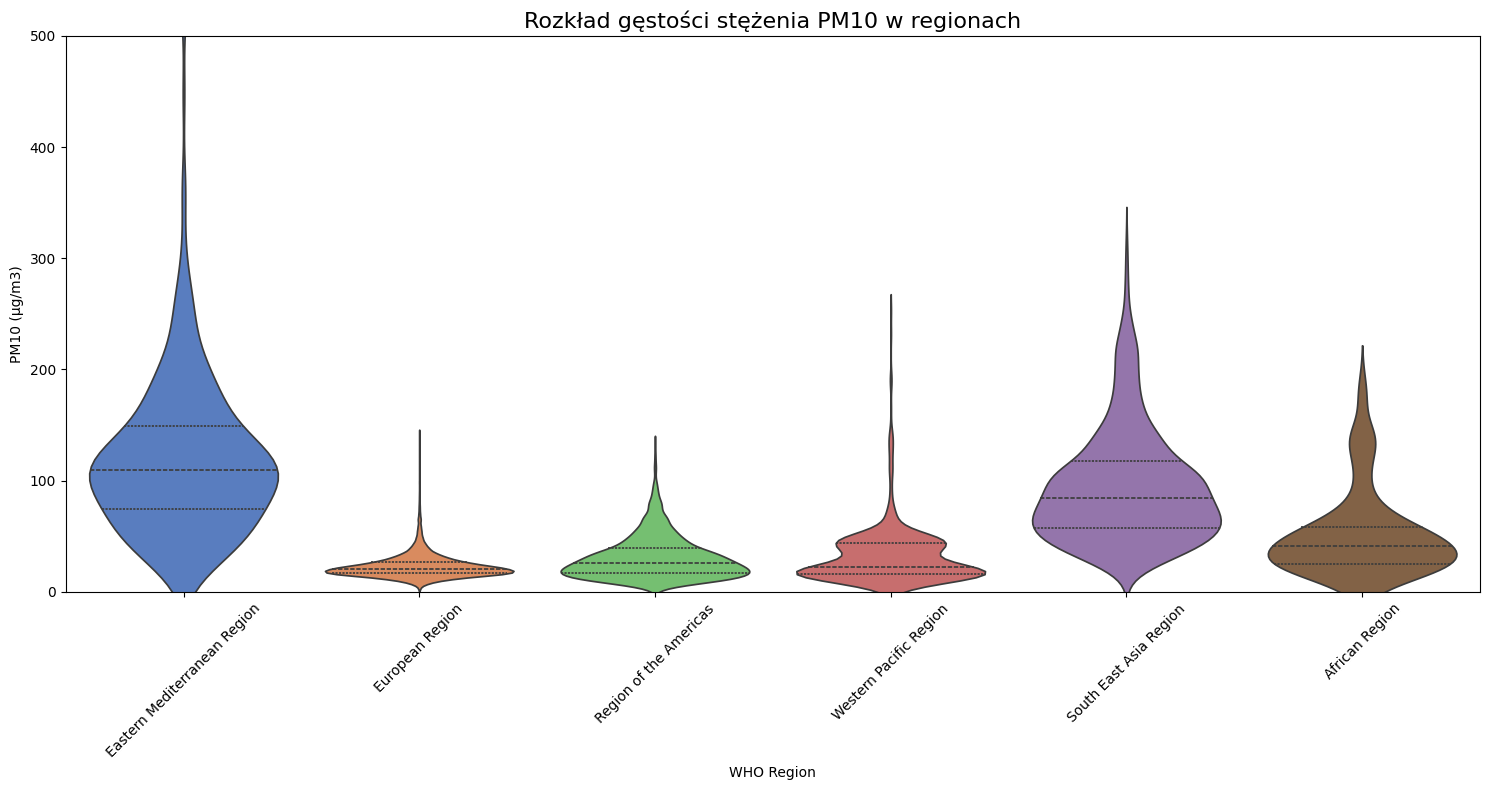

In [17]:
plt.figure(figsize=(15, 8))
sns.violinplot(
    data=data, 
    x='WHO Region', 
    y='PM10 (μg/m3)', 
    palette='muted', 
    inner='quartile',
)
plt.title('Rozkład gęstości stężenia PM10 w regionach', fontsize=16)
plt.xticks(rotation=45)

plt.ylim(0, 500) 
plt.tight_layout()
plt.show()

Generalizacja na **poziomie krajów** nie pozwala na porównanie ich wszystkich ze względu na ich ilość, więc ograniczamy się do np. prezentacji 15 krajów o najwyższym stężeniu PM.5


C:\Users\Dell\AppData\Local\Temp\ipykernel_12280\835181494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_pm25.values, y=country_pm25.index, palette='Reds_r')


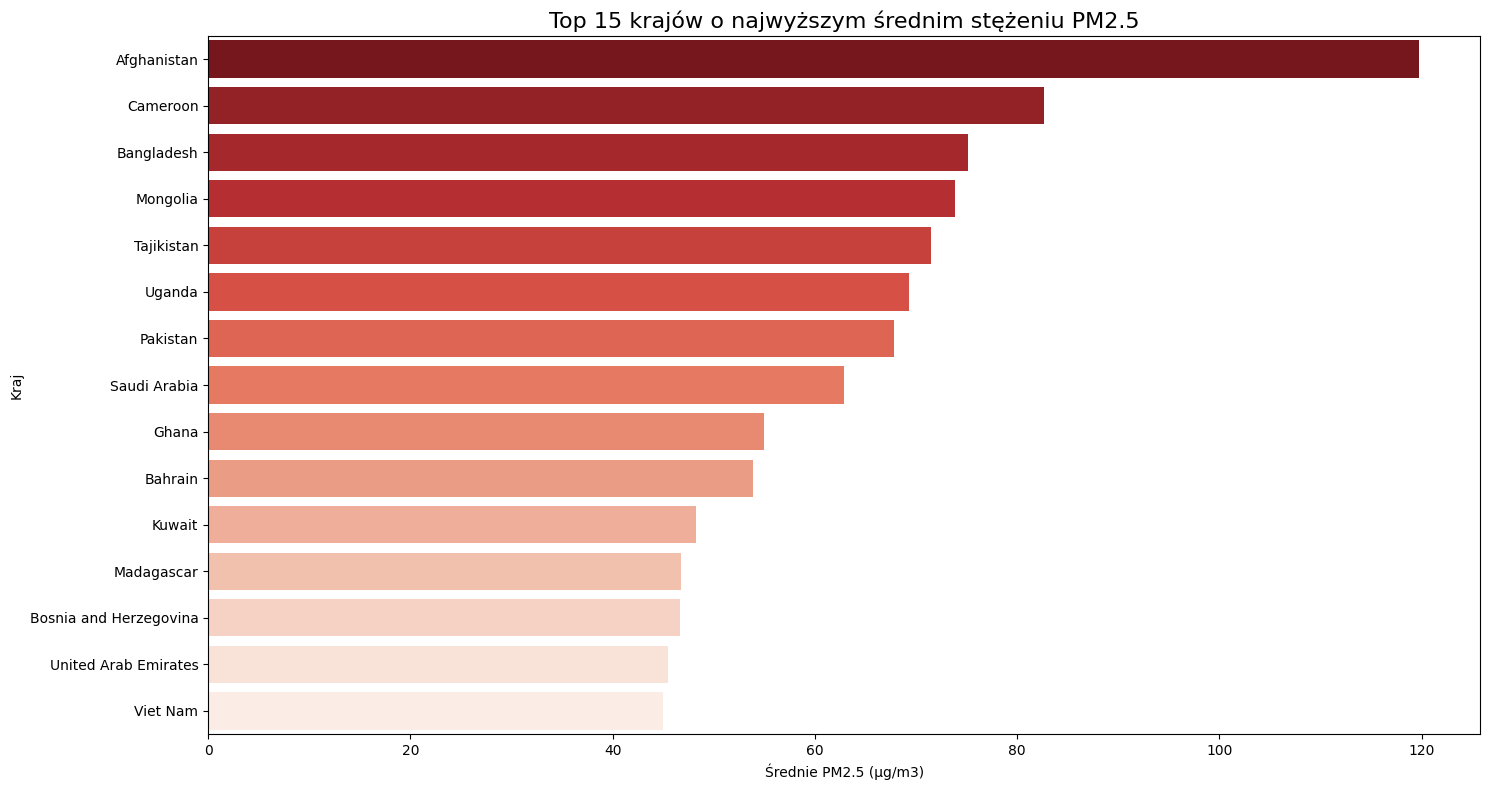

In [18]:
country_pm25 = data.groupby('WHO Country Name')['PM2.5 (μg/m3)'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(15, 8))
sns.barplot(x=country_pm25.values, y=country_pm25.index, palette='Reds_r')
plt.title('Top 15 krajów o najwyższym średnim stężeniu PM2.5', fontsize=16)
plt.xlabel('Średnie PM2.5 (μg/m3)')
plt.ylabel('Kraj')
plt.tight_layout()
plt.show()

Wyniki dla poszczególnych krajów oraz analiza średnich na poziomie regionów są ze sobą spójne. Kraje takie jak np. Afganistan, Cameroon, Bangladesh, Mongolia należą do regionów, w których wcześniej zaobserwowano najwyższe średnie wartości PM2.5 (Eastern Mediterranean, South East Asia, Western Pacific). Pokazuje to, że problem zanieczyszczenia powietrza jest skoncentrowany w określonych częściach świata.

Połączenie obu analiz (regionalnej i krajowej) pozwala lepiej zrozumieć skalę problemu – regiony wskazują ogólny trend, a analiza krajów pokazuje, które państwa odpowiadają za wysokie wartości. 

**Trend średniego stężenia PM2.5 na przestrzeni lat dla przykładowych krajów**

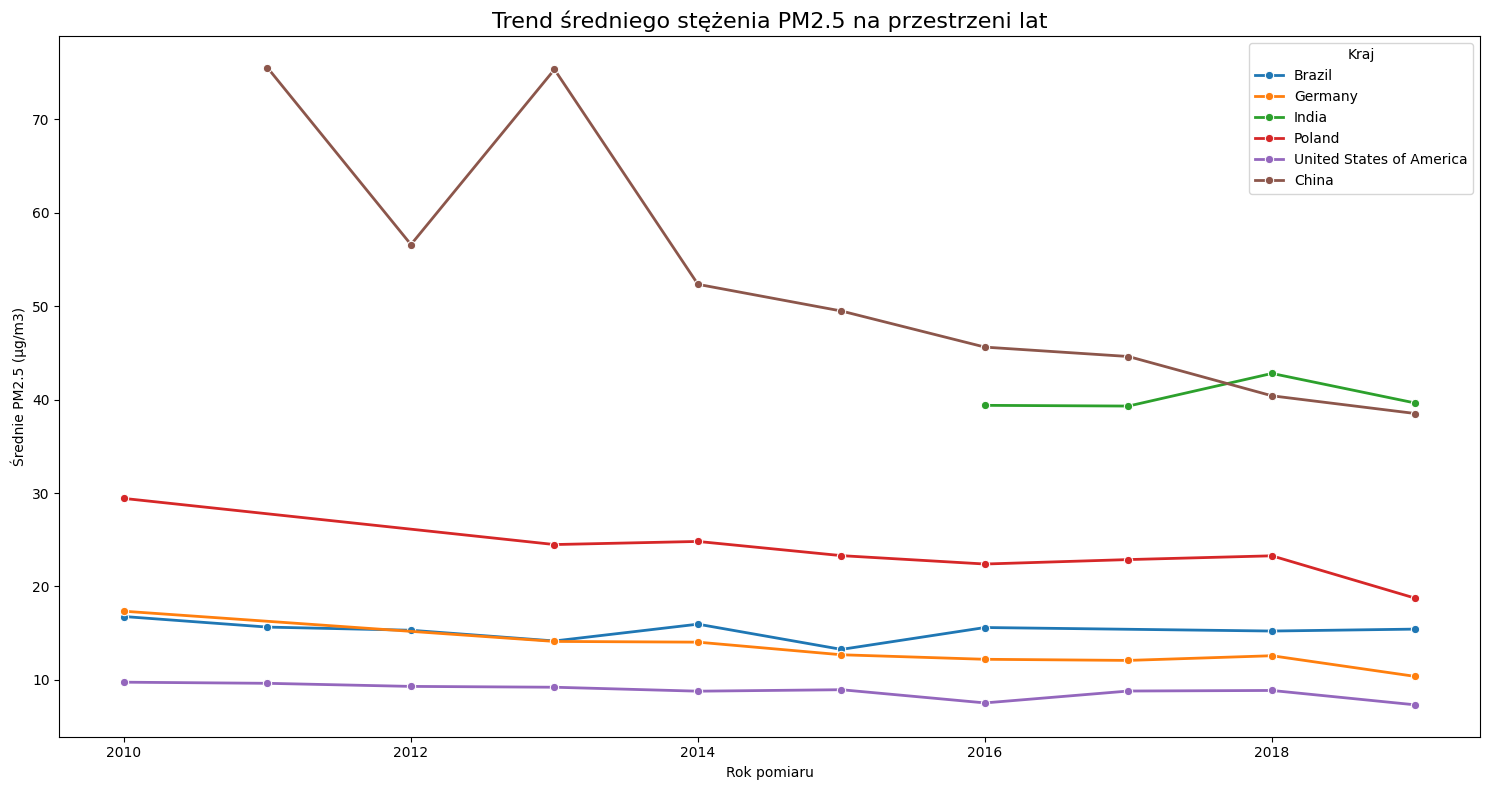

In [19]:
countries_to_plot = ['Poland', 'India', 'Germany', 'China','United States of America','Brazil']
trend_data = data[data['WHO Country Name'].isin(countries_to_plot)]
trend_grouped = trend_data.groupby(['Measurement Year', 'WHO Country Name'])['PM2.5 (μg/m3)'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(data=trend_grouped, x='Measurement Year', y='PM2.5 (μg/m3)', hue='WHO Country Name', marker='o', linewidth=2)
plt.title('Trend średniego stężenia PM2.5 na przestrzeni lat', fontsize=16)
plt.ylabel('Średnie PM2.5 (μg/m3)')
plt.xlabel('Rok pomiaru')
plt.legend(title='Kraj')
plt.tight_layout()
plt.show()

Możliwe jest porównywanie trendów na poziomie krajów, jednak taki poziom generalizacji ma swoje ograniczenia. Średnie wartości dla całych państw mogą ukrywać duże zróżnicowanie wewnętrzne. Przykładowo, porównanie średniej dla USA z średnią dla Polski nie oddaje rzeczywistych różnic między miastami czy regionami w obrębie tych krajów.

**Zależność między PM2.5 i PM10 na poziomie regionów**

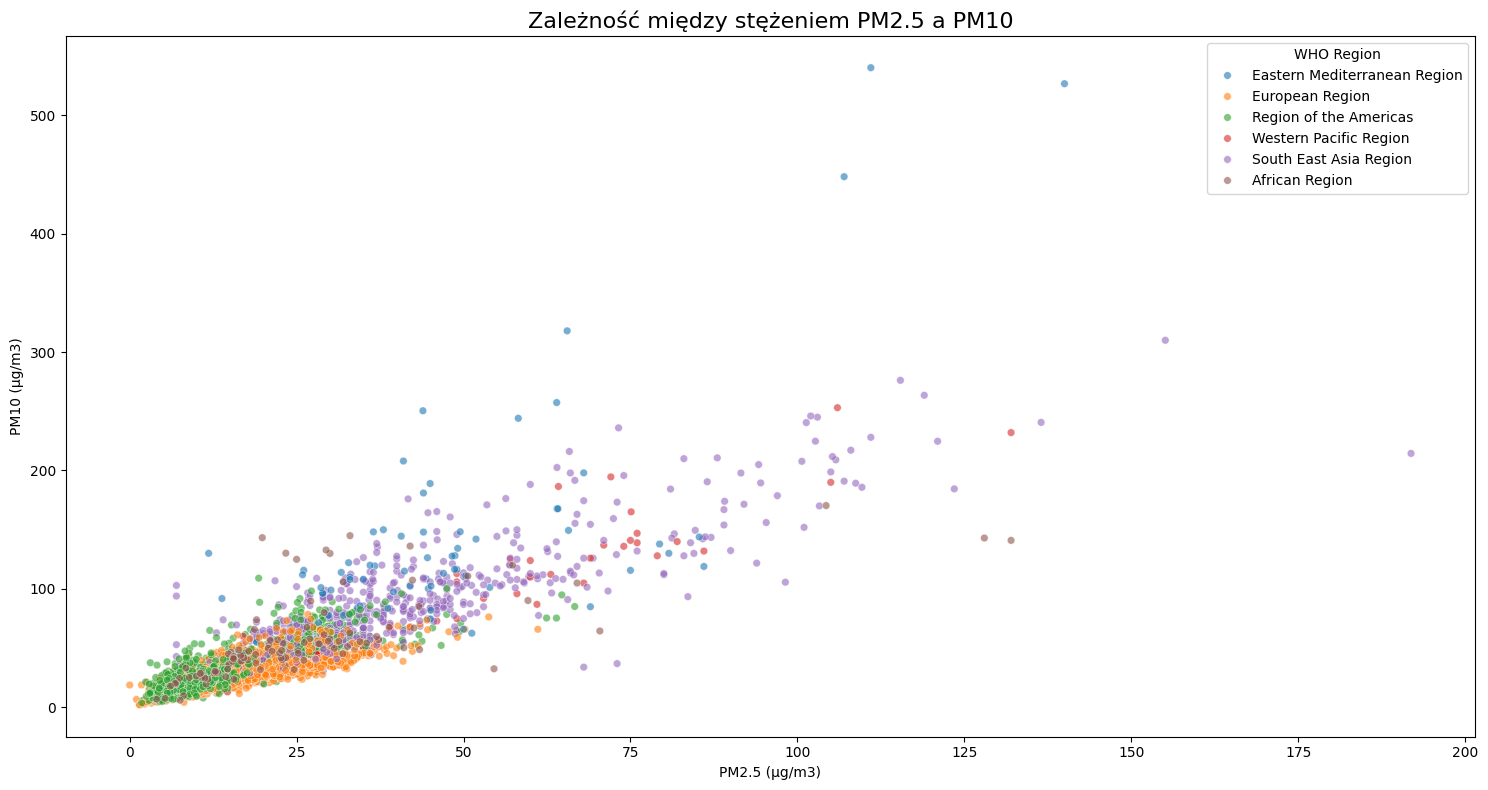

In [20]:
plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=data, 
    x='PM2.5 (μg/m3)', 
    y='PM10 (μg/m3)', 
    hue='WHO Region', 
    alpha=0.6, 
    s=30 
)

plt.title('Zależność między stężeniem PM2.5 a PM10', fontsize=16)
plt.tight_layout()
plt.show()

Na wykresie widać dodatnią zależność między PM2.5 a PM10, jednak wartości tych zmiennych znajdują się na różnych zakresach. Oś PM2.5 ma mniejszy zakres (skala co około 25), natomiast PM10 osiąga znacznie wyższe wartości (skala co około 100). Oznacza to, że choć oba zanieczyszczenia rosną razem, to PM10 przyjmuje znacznie większe wartości.

**Zależność między PM2.5 i NO2 w podziale na regiony**

Zdecydowano się użyć relplot, ponieważ punkty na wykresie scatterplot nachodizły na siebie i wykres był trudno do interpetacji.

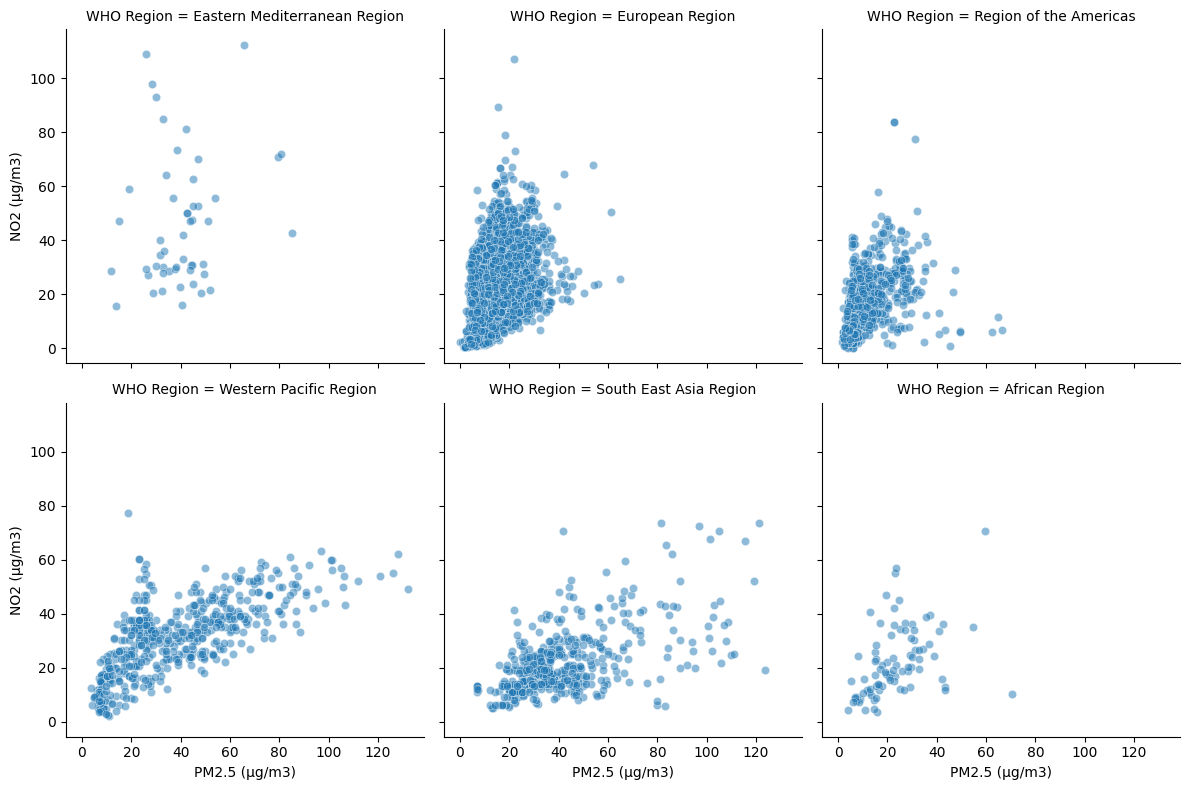

In [21]:
sns.relplot(
    data=data,
    x='PM2.5 (μg/m3)',
    y='NO2 (μg/m3)',
    col='WHO Region',
    col_wrap=3,
    height=4,
    alpha=0.5
)

W każdym regionie widoczna jest dodatnia zależność między zmiennymi, ale jej siła się różni. Zależności nie są uniwersalne globalnie.

**Top 15 miast z najwyższym stężeniem PM10**

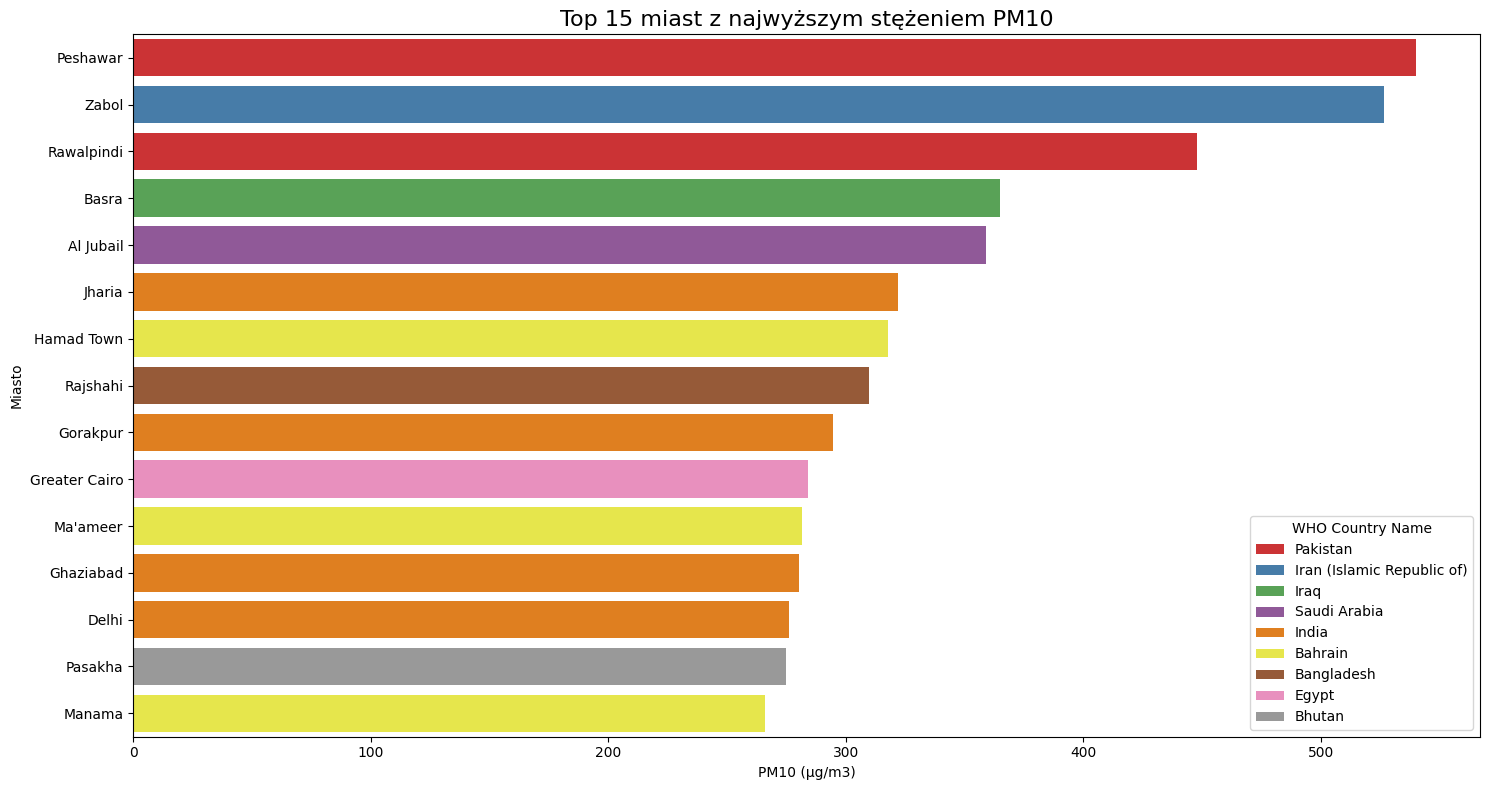

In [22]:
city_pm10 = data.groupby(['WHO Country Name', 'City or Locality'])['PM10 (μg/m3)'].max().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=city_pm10, x='PM10 (μg/m3)', y='City or Locality', hue='WHO Country Name', palette='Set1')
plt.title('Top 15 miast z najwyższym stężeniem PM10', fontsize=16)
plt.xlabel('PM10 (μg/m3)')
plt.ylabel('Miasto')
plt.tight_layout()
plt.show()


Analiza na poziomie miast daje bardziej szczegółowy obraz niż poziom krajów czy regionów, ponieważ pozwala wskazać konkretne miejsca o najwyższym ryzyku. Jednak bardzo duża liczba miast utrudnia analizę i jej czytelność, jednak dzięki skupieniu się na konkretnych, mniejszych obszarach możliwe jest uzyskanie bardziej miarodajnych i szczegółowych informacji.

**Wizualizacja współczynników korelacji Pearsona na 3 poziomach generalizacji pokazuje jak przydatne mogą być dane ze względy na punkt z którego na nie patrzymy**

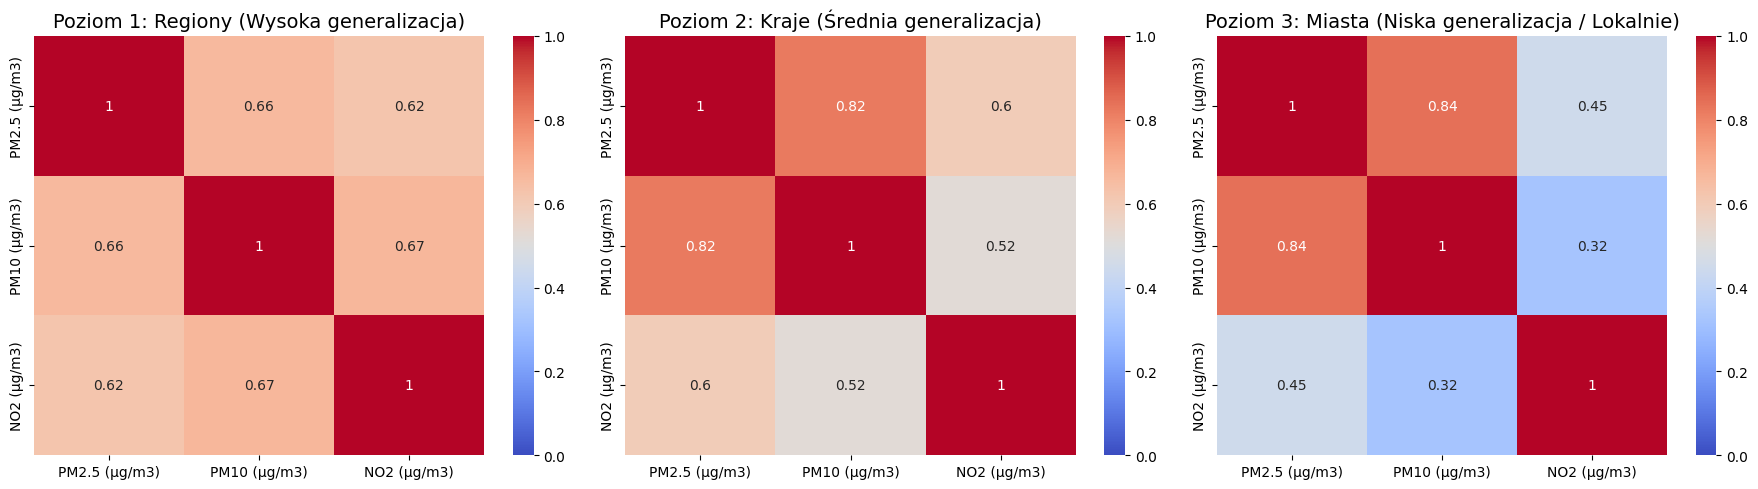

In [23]:
pollutants = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']

region_data = data.groupby('WHO Region')[pollutants].mean()
corr_region = region_data.corr()

country_data = data.groupby('WHO Country Name')[pollutants].mean()
corr_country = country_data.corr()

city_data = data.groupby([ 'City or Locality'])[pollutants].mean()
corr_city = city_data.corr()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
heatmap_kwargs = {'annot': True, 'cmap': 'coolwarm', 'vmin': 0, 'vmax': 1}

sns.heatmap(corr_region, ax=axes[0], **heatmap_kwargs)
axes[0].set_title('Poziom 1: Regiony (Wysoka generalizacja)', fontsize=14)
sns.heatmap(corr_country, ax=axes[1], **heatmap_kwargs)
axes[1].set_title('Poziom 2: Kraje (Średnia generalizacja)', fontsize=14)
sns.heatmap(corr_city, ax=axes[2], **heatmap_kwargs)
axes[2].set_title('Poziom 3: Miasta (Niska generalizacja / Lokalnie)', fontsize=14)

plt.tight_layout()
plt.show()

Na poziomie regionów zależności między wszystkimi zmiennymi są umiarkowane i dość podobne (ok. 0.62–0.67), co oznacza, że zanieczyszczenia są ze sobą powiązane, ale bez bardzo silnej zależności.

Na poziomie krajów zależność między PM2.5 a PM10 jest bardzo silna (0.82), co sugeruje wspólne źródła emisji. Zależność z NO2 jest słabsza, co oznacza, że NO2 może mieć inne źródła.

Na poziomie miast zależność między PM2.5 a PM10 pozostaje bardzo silna (0.84), natomiast zależności z NO2 są wyraźnie słabsze (0.32–0.45), co wskazuje na większą zmienność lokalną i różne źródła zanieczyszczeń.

Oznacza to, że poziom generalizacji ma istotny wpływ na interpretację współczynników korelacji Pearsona – agregacja danych może wzmacniać lub wygładzać zależności, które na poziomie lokalnym są bardziej zróżnicowane.

**Analiza współczynników korelacji Pearsona w podziale na regiony**

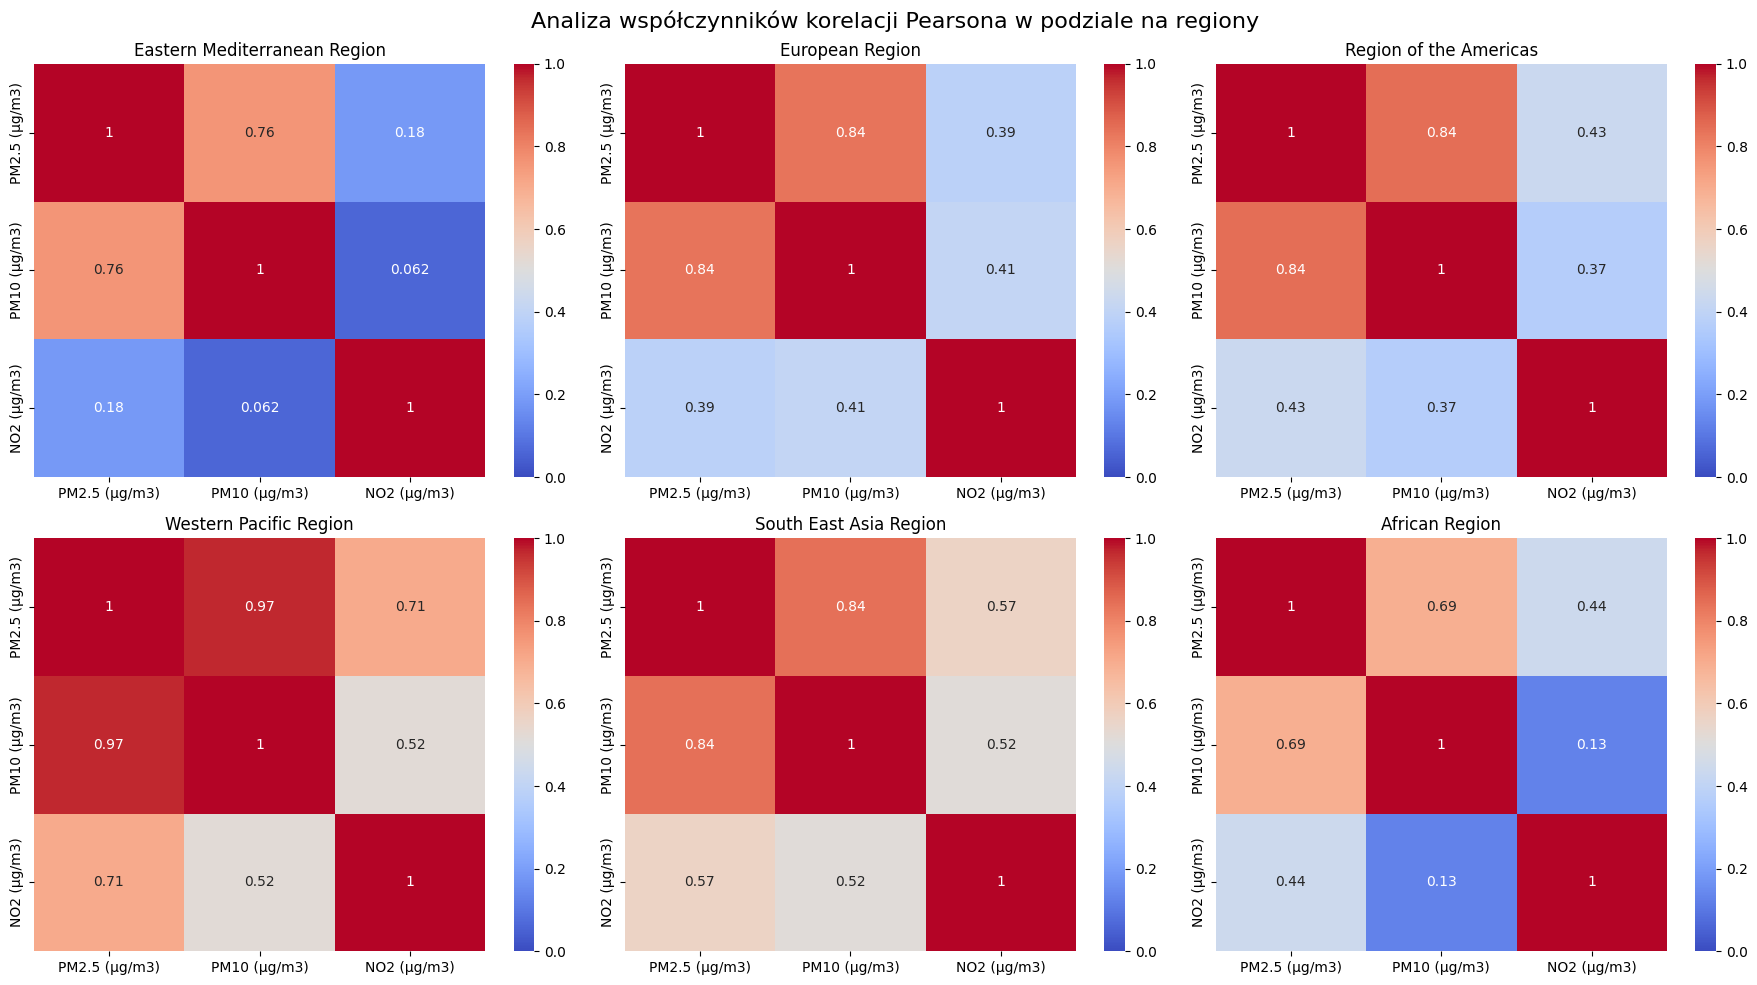

In [24]:
regions = data['WHO Region'].dropna().unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, region in zip(axes, regions):
    df_region = data[data['WHO Region'] == region]
    
    corr = df_region[pollutants].corr()
    
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=0,
        vmax=1,
        ax=ax
    )
    
    ax.set_title(region, fontsize=12)

for i in range(len(regions), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Analiza współczynników korelacji Pearsona w podziale na regiony', fontsize=16)
plt.tight_layout()
plt.show()

Wyniki pokazują, że zależności między zmiennymi różnią się istotnie w zależności od regionu. Przykładowo, w regionie Eastern Mediterranean zależność między PM10 a NO2 jest bardzo słaba (ok. 0.06), natomiast w regionach takich jak South East Asia czy Western Pacific osiąga już wartości umiarkowane (ok. 0.5). Patrząc również na zależność między PM2.5, a NO2, jest ona słaba (0.18) dla regionu Eastern Mediterranean, podczas gdy ta sama zależnosć dla Western Pacific Region jest równa 0.71.

Oznacza to, że analiza korelacji jedynie w ujęciu ogólnym lub globalnym może prowadzić do uproszczeń i pominięcia istotnych różnic. 

**Analiza współczynników korelacji Pearsona dla wybranych krajów Azji**

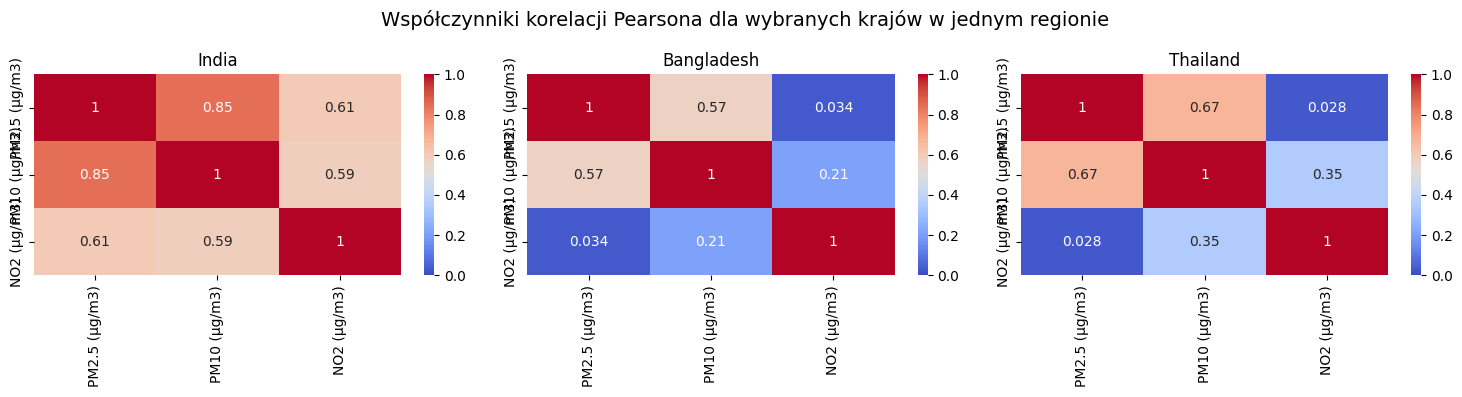

In [25]:
pollutants = ['PM2.5 (μg/m3)', 'PM10 (μg/m3)', 'NO2 (μg/m3)']
countries = ['India', 'Bangladesh', 'Thailand']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, country in zip(axes, countries):
    df_country = data[data['WHO Country Name'] == country].dropna(subset=pollutants)
    corr = df_country[pollutants].corr(method='pearson')
    
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=0,
        vmax=1,
        ax=ax
    )
    ax.set_title(country)

plt.suptitle('Współczynniki korelacji Pearsona dla wybranych krajów w jednym regionie', fontsize=14)
plt.tight_layout()
plt.show()

Analiza współczynników korelacji Pearsona dla wybranych krajów (India, Bangladesh, Thailand) pokazuje, że zależności między zanieczyszczeniami mogą się istotnie różnić nawet w obrębie tego samego regionu.

W ujęciu ogólnym dla regionu South East Asia obserwowano umiarkowane zależności między zmiennymi (np. PM10–NO2 na poziomie ok. 0.5). Jednak po przejściu na poziom poszczególnych krajów okazuje się, że wartości te nie są jednorodne – w Bangladeszu wynik ten jest na pozimie niższym (0.21). Patrząc na zależność między zmiennymi PM2.5 a NO2, widzimy, że w Indiach jest ona na poziomie około 0.61 (zbliżona do wartości dla całego regionu – ok. 0.57). Jednak w Bangladeszu i Tajlandii współczynnik ten jest znacznie niższy i wynosi odpowiednio około 0.03.

Pokazuje to, że wartość korelacji na poziomie regionu nie odzwierciedla rzeczywistych zależności występujących w poszczególnych krajach. W praktyce oznacza to, że analiza uśredniona dla regionu może sugerować umiarkowaną zależność między zmiennymi, podczas gdy w części państw zależność ta jest bardzo słaba lub wręcz pomijalna.

Dekompozycja trendu na sezonowość jest raczej bezcelowa ze względy na brak podziału danych na miesiące, a jedynie na lata, co uniemożliwia analizę sezonowości w ciągu roku.

**Porównanie średnich i median dla poszczególnych regionów oraz krajów**

In [26]:
region_stats = data.groupby('WHO Region')[pollutants].agg(['mean', 'median']).round(1)
region_stats.columns = ['_'.join(c) for c in region_stats.columns]

country_stats = data.groupby('WHO Country Name')[pollutants].agg(['mean', 'median']).round(1)
country_stats.columns = ['_'.join(c) for c in country_stats.columns]

print('Statystyki na poziomie REGIONU:')
display(region_stats)
print('Statystyki na poziomie KRAJU:')
display(country_stats)

Statystyki na poziomie REGIONU:


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Statystyki na poziomie KRAJU:


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Mediana lepiej oddaje typowe miasta w regionie/kraju, ponieważ jest mniej podatna na wartości odstające.
Za pomocą ich porównania można ocenić rozkład danych i skośność oraz obecność wartości odstających.
Różnica wartości (niższa mediana) wskazuje na występowanie miast o bardzo wysokim zanieczyszczeniu.

**Wizualizacja średnich i median dla poszczególnych regionów dla PM2.5**

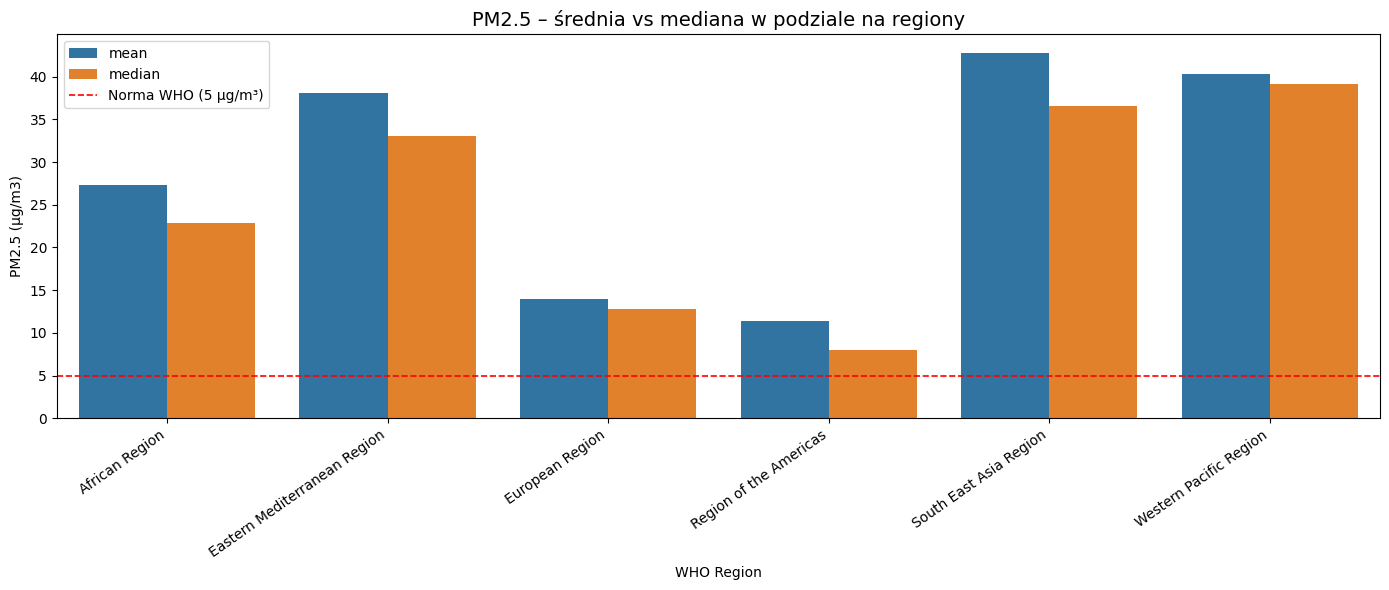

In [27]:
region_stats = data.groupby('WHO Region')['PM2.5 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='PM2.5 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='PM2.5 (μg/m3)', hue='Statystyka')
plt.axhline(5, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (5 μg/m³)')
plt.title('PM2.5 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Dla krajów jest to niemożliwe do wizualizacji w ten sposób ze względu na ilość.

We wszystkich regionach średnia jest wyższa od mediany, co wskazuje na prawostronną skośność rozkładu – występują wysokie wartości, które zawyżają średnią.
Najwyższe wartości PM2.5 występują w regionach South-East Asia, Western Pacific oraz Eastern Mediterranean, co potwierdza wcześniejsze analizy.

W każdym regionie zarówno średnia, jak i mediana są znacznie powyżej poziomu zalecanego przez WHO, co wskazuje na powszechny problem zanieczyszczenia powietrza.

**Wizualizacja średnich i median dla poszczególnych regionów dla PM10**

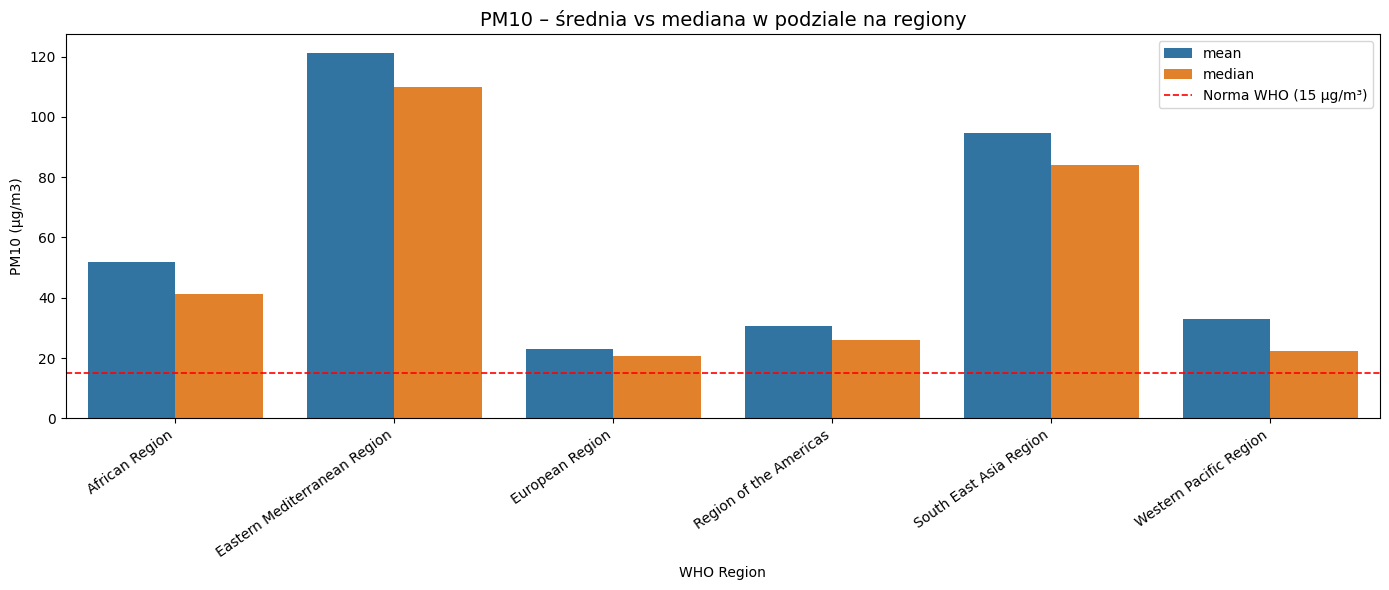

In [28]:
region_stats = data.groupby('WHO Region')['PM10 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='PM10 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='PM10 (μg/m3)', hue='Statystyka')
plt.axhline(15, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (15 μg/m³)')
plt.title('PM10 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

We wszystkich regionach średnia jest wyższa od mediany, co wskazuje na obecność wysokich wartości odstających zawyżających średnią.

Najwyższe poziomy PM10 występują w regionach Eastern Mediterranean oraz South-East Asia, co potwierdza ich duży problem z zanieczyszczeniem powietrza.

Najniższe wartości obserwowane są w Europie, jednak nawet tam średnia i mediana przekraczają normę WHO.

**Wizualizacja średnich i median dla poszczególnych regionów dla NO2**

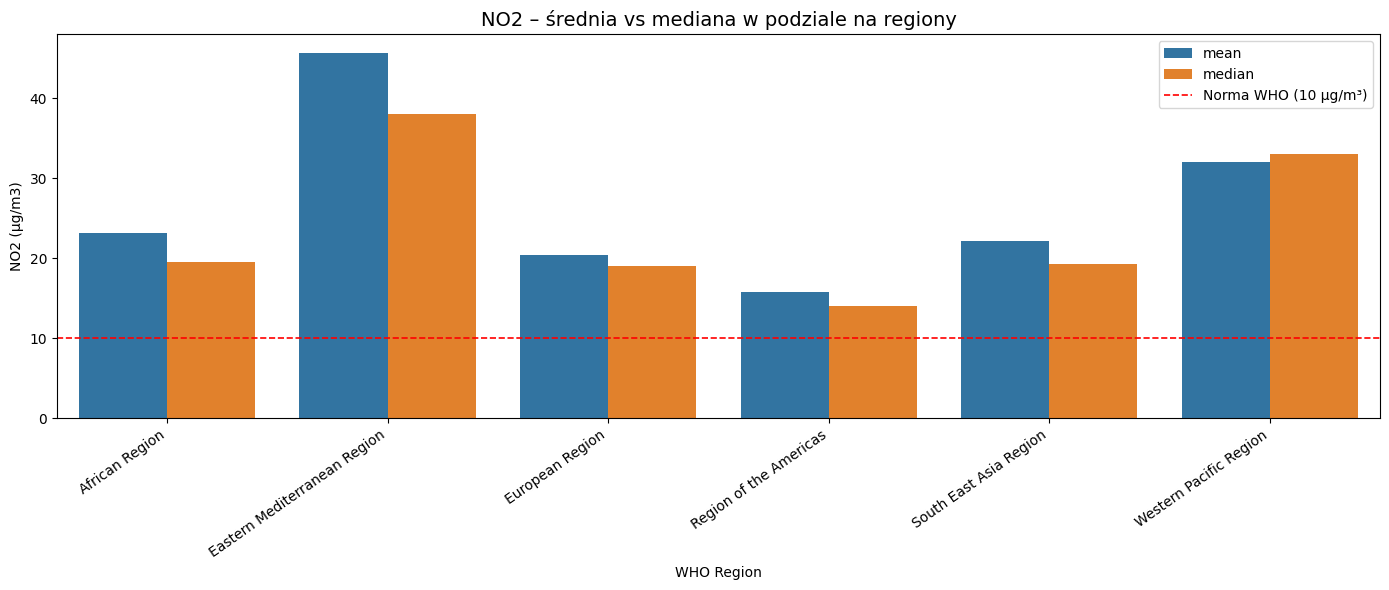

In [29]:
region_stats = data.groupby('WHO Region')['NO2 (μg/m3)'].agg(['mean', 'median']).round(1).reset_index()
region_stats_melted = region_stats.melt(id_vars='WHO Region', var_name='Statystyka', value_name='NO2 (μg/m3)')

plt.figure(figsize=(14, 6))
sns.barplot(data=region_stats_melted, x='WHO Region', y='NO2 (μg/m3)', hue='Statystyka')
plt.axhline(10, color='red', linestyle='--', linewidth=1.2, label='Norma WHO (10 μg/m³)')
plt.title('NO2 – średnia vs mediana w podziale na regiony', fontsize=14)
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Niezależnie od regionu poziom NO2 przekracza normy WHO, co potwierdza globalny charakter problemu zanieczyszczenia powietrza.

**Odsetek miast przekraczających normy WHO w każdym regionie.**

In [30]:
WHO_LIMITS = {'PM2.5 (μg/m3)': 5, 'PM10 (μg/m3)': 15, 'NO2 (μg/m3)': 10}
 
exceed = {}
for region, grp in data.groupby('WHO Region'):
    exceed[region] = {p: (grp[p].dropna() > WHO_LIMITS[p]).mean() * 100 for p in pollutants}
 
exceed_df = pd.DataFrame(exceed).T.round(1)
it.show(exceed_df, classes="display", style="")

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


We wszystkich regionach zdecydowana większość pomiarów przekracza normy WHO, co wskazuje na globalny charakter problemu zanieczyszczenia powietrza.

Najgorsza sytuacja występuje w regionach Eastern Mediterranean oraz South East Asia, gdzie niemal 100% pomiarów dla PM2.5 i PM10 przekracza normy.

Region Afrykański również charakteryzuje się bardzo wysokim poziomem przekroczeń, szczególnie dla PM2.5 i PM10.

Najlepsza sytuacja występuje w Regionie Ameryk, gdzie odsetek przekroczeń jest najniższy, choć nadal bardzo wysoki (ponad 80% dla PM2.5 i PM10).

Potwierdza to wnioski stwierdzone z powyższych wykresów.

**IQR - rozrzut wartości PM2.5 między miastami w danym kraju.**

C:\Users\Dell\AppData\Local\Temp\ipykernel_12280\2932170937.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Reds_r')


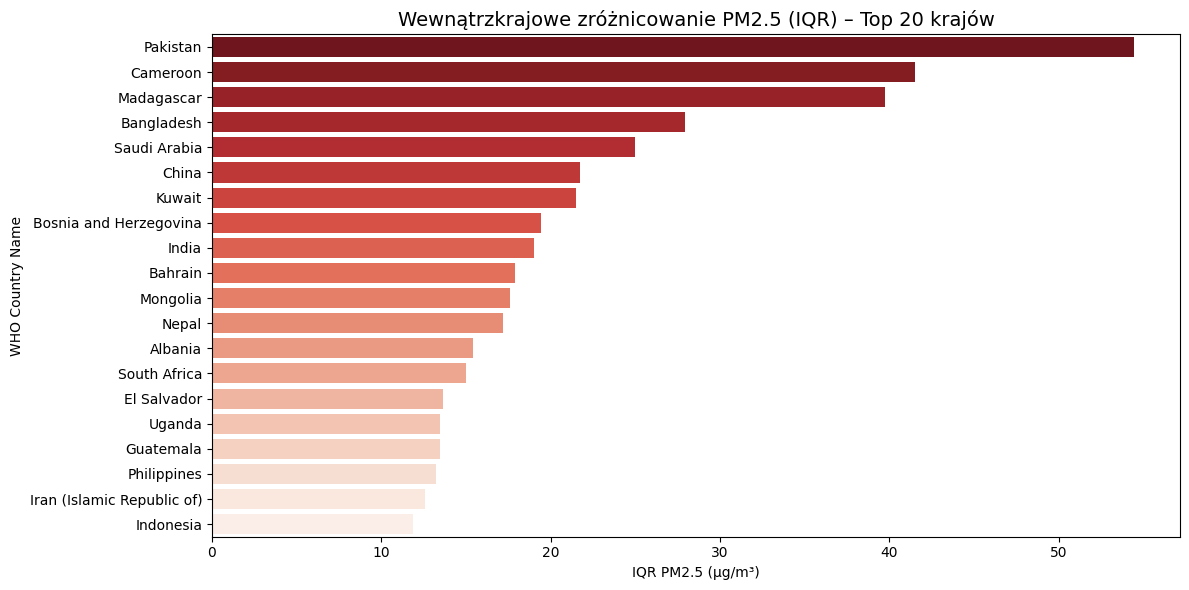

In [31]:
country_iqr = (
    data.groupby('WHO Country Name')['PM2.5 (μg/m3)']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)
 
plt.figure(figsize=(12, 6))
sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Reds_r')
plt.title('Wewnątrzkrajowe zróżnicowanie PM2.5 (IQR) – Top 20 krajów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

Wykres pokazuje duże zróżnicowanie poziomu PM2.5 wewnątrz niektórych krajów. Największy rozrzut wartości (wysoki IQR) występuje m.in. w Pakistanie, Kamerunie i Madagaskarze, co oznacza duże różnice między miastami.

W krajach z wysokim IQR średnia krajowa może być mało reprezentatywna, ponieważ poszczególne miasta znacząco się od siebie różnią pod względem zanieczyszczenia.

Z kolei kraje z niższym IQR mają bardziej wyrównane wartości PM2.5, co oznacza, że średnia lepiej opisuje sytuację w całym kraju.

**IQR - bottom 20 krajów dla wartości PM2.5**

C:\Users\Dell\AppData\Local\Temp\ipykernel_12280\1112631662.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Blues_r')


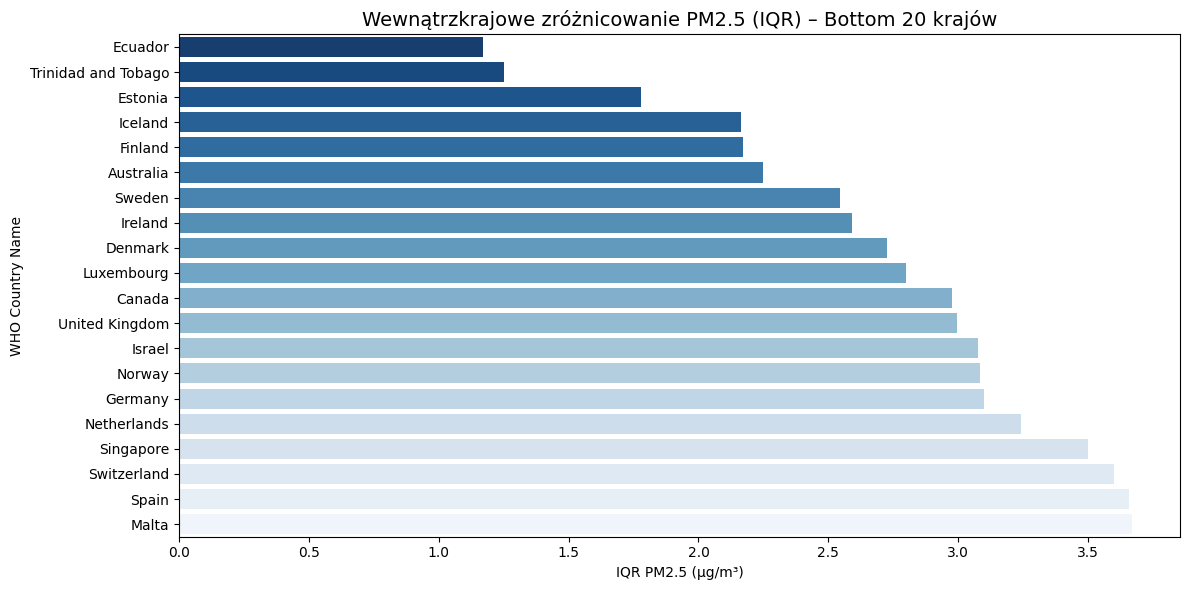

In [32]:
country_iqr = (
    data.groupby('WHO Country Name')['PM2.5 (μg/m3)']
    .apply(lambda x: x.dropna().quantile(0.75) - x.dropna().quantile(0.25)
           if x.dropna().count() >= 5 else np.nan)
    .dropna()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_iqr.values, y=country_iqr.index, palette='Blues_r')
plt.title('Wewnątrzkrajowe zróżnicowanie PM2.5 (IQR) – Bottom 20 krajów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

W krajach z najniższym IQR wartości PM2.5 są bardzo wyrównane między miastami, co oznacza małe zróżnicowanie wewnętrzne.

Oznacza to, że poziom zanieczyszczenia jest w tych krajach bardziej stabilny i podobny niezależnie od lokalizacji. Są to kraje w większości z Europy. 
W takich przypadkach średnia krajowa dobrze odzwierciedla rzeczywistą sytuację i może być uznana za reprezentatywną.

**IQR - rozrzut wartości PM2.5 między miastami w danym regionie**

C:\Users\Dell\AppData\Local\Temp\ipykernel_12280\3870782244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_iqr.values, y=region_iqr.index, palette='Blues_r')


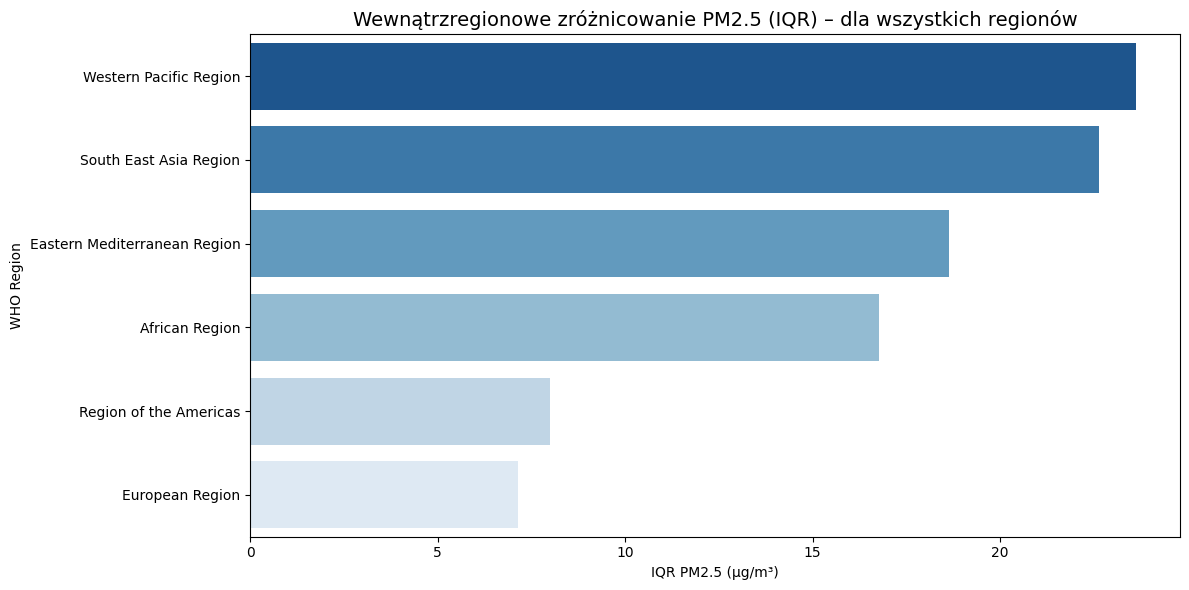

In [33]:
region_iqr = (
    data.groupby('WHO Region')['PM2.5 (μg/m3)']
    .apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)
 
plt.figure(figsize=(12, 6))
sns.barplot(x=region_iqr.values, y=region_iqr.index, palette='Blues_r')
plt.title('Wewnątrzregionowe zróżnicowanie PM2.5 (IQR) – dla wszystkich regionów', fontsize=14)
plt.xlabel('IQR PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

Największe zróżnicowanie wartości PM2.5 występuje w regionach Western Pacific oraz South-East Asia, co oznacza duże różnice między miastami w tych obszarach.
Średnie zróżnicowanie obserwujemy w regionach Eastern Mediterranean i African Region.

Analiza na poziomie regionów pokazuje ogólny poziom zróżnicowania w dużych obszarach świata, a nie tylko w pojedynczych krajach.
Przy krajach widać było konkretne przypadki (np. Pakistan z dużą wartością), a przy regionach widać czy całe części świata są bardziej zróżnicowane.

**Porównanie trendu PM2.5 dla wybranych miast z trendem ich kraju**

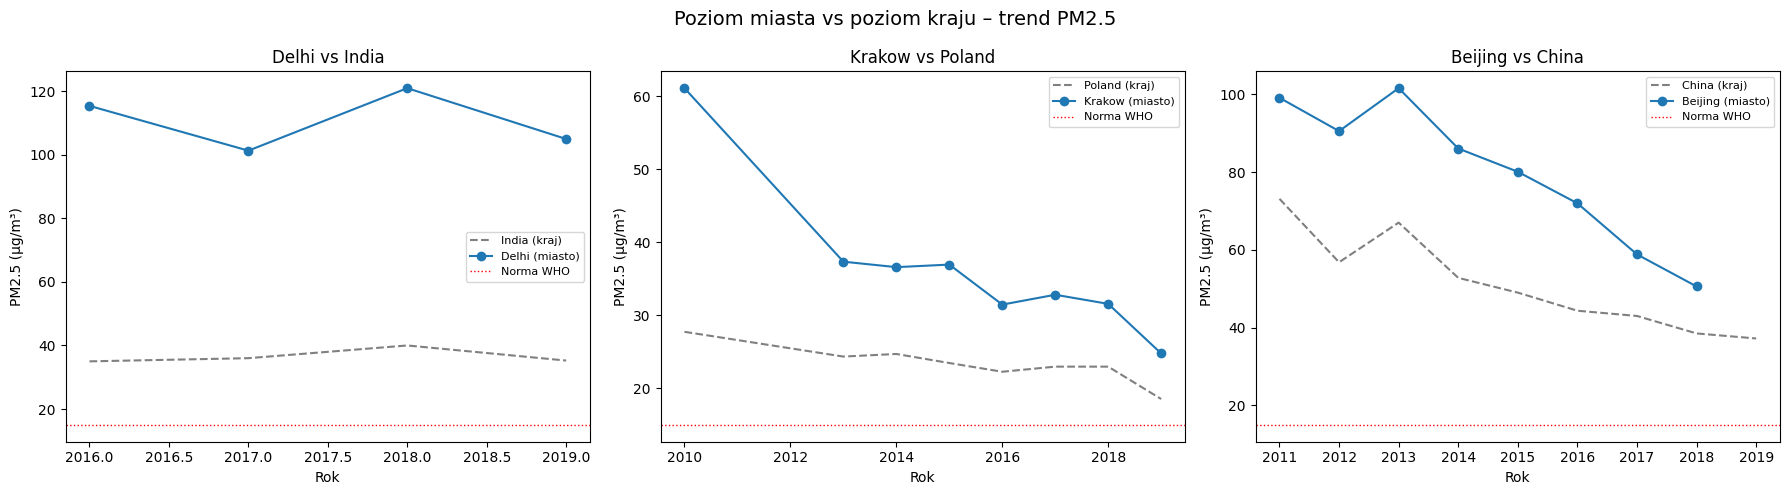

In [34]:
pairs = [('Delhi', 'India'), ('Krakow', 'Poland'), ('Beijing', 'China')]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for ax, (city, country) in zip(axes, pairs):
    city_trend = (
        data[data['City or Locality'] == city]
        .groupby('Measurement Year')['PM2.5 (μg/m3)'].median().reset_index()
    )
    country_trend = (
        data[data['WHO Country Name'] == country]
        .groupby('Measurement Year')['PM2.5 (μg/m3)'].median().reset_index()
    )
    ax.plot(country_trend['Measurement Year'], country_trend['PM2.5 (μg/m3)'],
            linestyle='--', color='gray', label=f'{country} (kraj)')
    ax.plot(city_trend['Measurement Year'], city_trend['PM2.5 (μg/m3)'],
            marker='o', label=f'{city} (miasto)')
    ax.axhline(15, color='red', linestyle=':', linewidth=1, label='Norma WHO')
    ax.set_title(f'{city} vs {country}', fontsize=12)
    ax.set_xlabel('Rok')
    ax.set_ylabel('PM2.5 (μg/m³)')
    ax.legend(fontsize=8)
 
plt.suptitle('Poziom miasta vs poziom kraju – trend PM2.5', fontsize=14)
plt.tight_layout()
plt.show()

We wszystkich przypadkach wartości dla miast są wyższe niż średnie krajowe, co oznacza, że duże miasta są bardziej zanieczyszczone niż średnia dla całego kraju.

Największa różnica widoczna jest dla Delhi – poziom w mieście jest znacznie wyższy niż średnia krajowa, co pokazuje silne zróżnicowanie wewnętrzne.

Dla Beijing i Chin widoczny jest spadek zanieczyszczeń w czasie, zarówno na poziomie miasta, jak i kraju, co może świadczyć o skutecznych działaniach ograniczających emisję.

We wszystkich przypadkach wartości przekraczają normy WHO.

**Agregacja danych PM2.5 na trzech poziomach generalizacji**

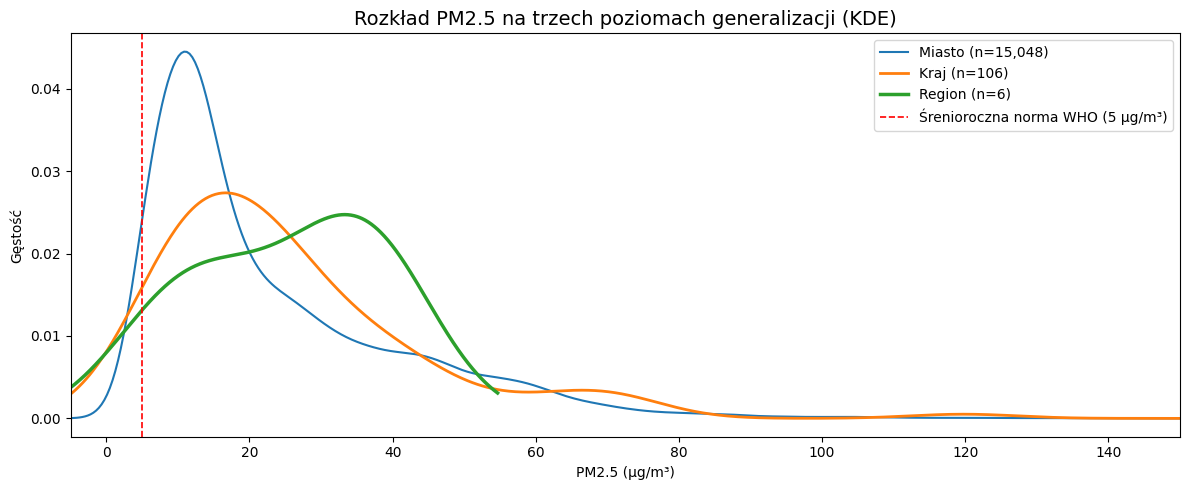

In [35]:
pm25_city    = data['PM2.5 (μg/m3)'].dropna()
pm25_country = data.groupby('WHO Country Name')['PM2.5 (μg/m3)'].median().dropna()
pm25_region  = data.groupby('WHO Region')['PM2.5 (μg/m3)'].median().dropna()
 
plt.figure(figsize=(12, 5))
pm25_city.plot.kde(label=f'Miasto (n={len(pm25_city):,})', linewidth=1.5)
pm25_country.plot.kde(label=f'Kraj (n={len(pm25_country)})', linewidth=2)
pm25_region.plot.kde(label=f'Region (n={len(pm25_region)})', linewidth=2.5)
plt.axvline(5, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (5 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład PM2.5 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Wykres pokazuje, że rozkład PM2.5 różni się w zależności od poziomu agregacji danych. Na poziomie miast rozkład jest najbardziej skoncentrowany w niższych wartościach, z maksimum w okolicach około 10–15. Oznacza to, że większość miast ma umiarkowane stężenia PM2.5, ale widoczny jest długi prawostronny ogon, co wskazuje na obecność miast o bardzo wysokim zanieczyszczeniu.

Na poziomie krajów rozkład przesuwa się w prawo i staje się bardziej spłaszczony. Sugeruje to większe zróżnicowanie średnich wartości pomiędzy krajami oraz obecność kilku państw o bardzo wysokich poziomach.

Na poziomie regionów rozkład jest jeszcze bardziej wygładzony i przesunięty ku wyższym wartościom. Wynika to z silniejszej generalizacji danych - uśrednianie na poziomie dużych obszarów zmniejsza wpływ lokalnych ekstremów, ale jednocześnie podkreśla ogólne różnice między regionami świata.

**Agregacja danych PM10 na trzech poziomach generalizacji**

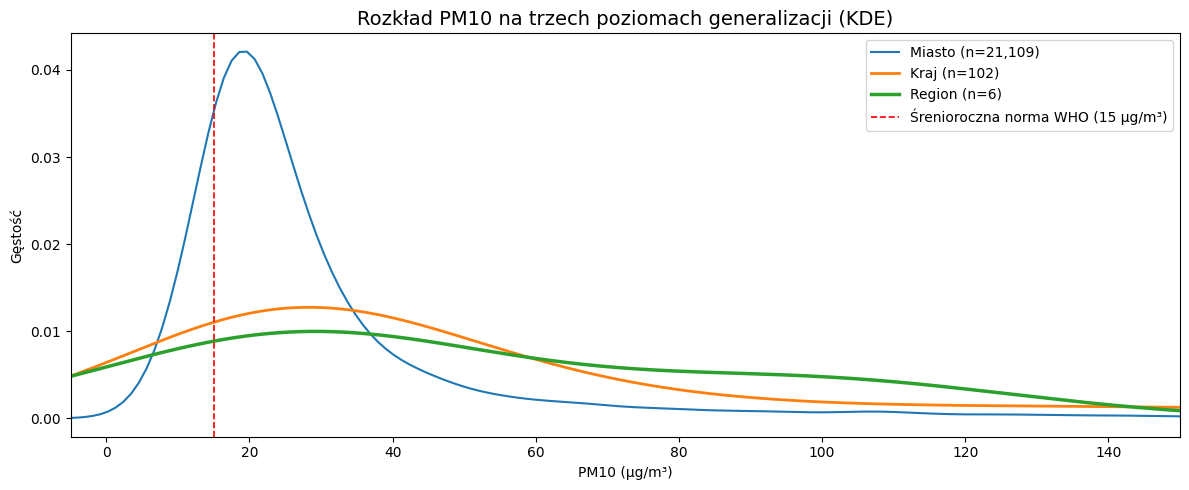

In [36]:
pm10_city    = data['PM10 (μg/m3)'].dropna()
pm10_country = data.groupby('WHO Country Name')['PM10 (μg/m3)'].median().dropna()
pm10_region  = data.groupby('WHO Region')['PM10 (μg/m3)'].median().dropna()

plt.figure(figsize=(12, 5))
pm10_city.plot.kde(label=f'Miasto (n={len(pm10_city):,})', linewidth=1.5)
pm10_country.plot.kde(label=f'Kraj (n={len(pm10_country)})', linewidth=2)
pm10_region.plot.kde(label=f'Region (n={len(pm10_region)})', linewidth=2.5)
plt.axvline(15, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (15 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('PM10 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład PM10 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Na poziomie miast rozkład jest najbardziej skupiony, z maksimum w okolicach 20–25. Jednocześnie widoczny jest długi ogon w prawo.

Na poziomie krajów rozkład staje się bardziej spłaszczony i przesunięty w stronę wyższych wartości. Wskazuje to na większe zróżnicowanie średnich poziomów PM10 pomiędzy państwami oraz obecność krajów o bardzo wysokim zanieczyszczeniu.

Na poziomie regionów rozkład jest jeszcze bardziej wygładzony i obejmuje szeroki zakres wartości. Wynika to z silnej generalizacji danych – uśrednianie na poziomie dużych obszarów maskuje lokalne różnice, ale pokazuje globalne dysproporcje.

**Agregacja danych NO2 na trzech poziomach generalizacji**

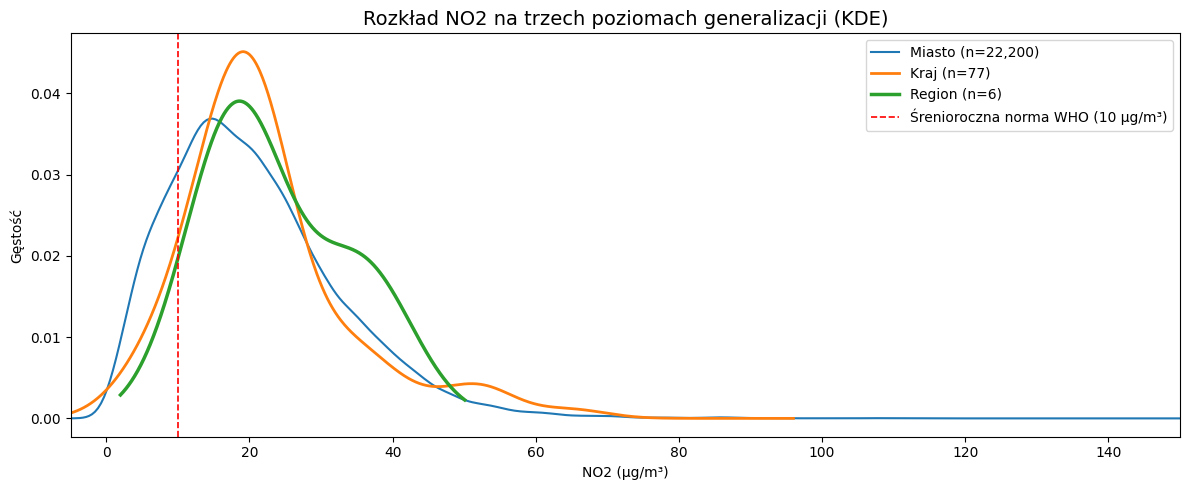

In [37]:
no2_city    = data['NO2 (μg/m3)'].dropna()
no2_country = data.groupby('WHO Country Name')['NO2 (μg/m3)'].median().dropna()
no2_region  = data.groupby('WHO Region')['NO2 (μg/m3)'].median().dropna()

plt.figure(figsize=(12, 5))
no2_city.plot.kde(label=f'Miasto (n={len(no2_city):,})', linewidth=1.5)
no2_country.plot.kde(label=f'Kraj (n={len(no2_country)})', linewidth=2)
no2_region.plot.kde(label=f'Region (n={len(no2_region)})', linewidth=2.5)
plt.axvline(10, color='red', linestyle='--', linewidth=1.2, label='Śrenioroczna norma WHO (10 μg/m³)')
plt.xlim(-5, 150)
plt.xlabel('NO2 (μg/m³)')
plt.ylabel('Gęstość')
plt.title('Rozkład NO2 na trzech poziomach generalizacji (KDE)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

Rozkłady dla wszystkich poziomów są bardziej skupione niż dla pyłów, co oznacza mniejszą zmienność NO2.

Na poziomie miast widoczna jest większa zmienność i dłuższy ogon rozkładu, co wskazuje na lokalne przypadki wysokich stężeń.

Na poziomie krajów i regionów rozkłady są bardziej wygładzone, co wynika z uśredniania danych.

**Współczynnik zmienności (CV) - pokazuje zróżnicowanie danych na trzech poziomach generalizacji**

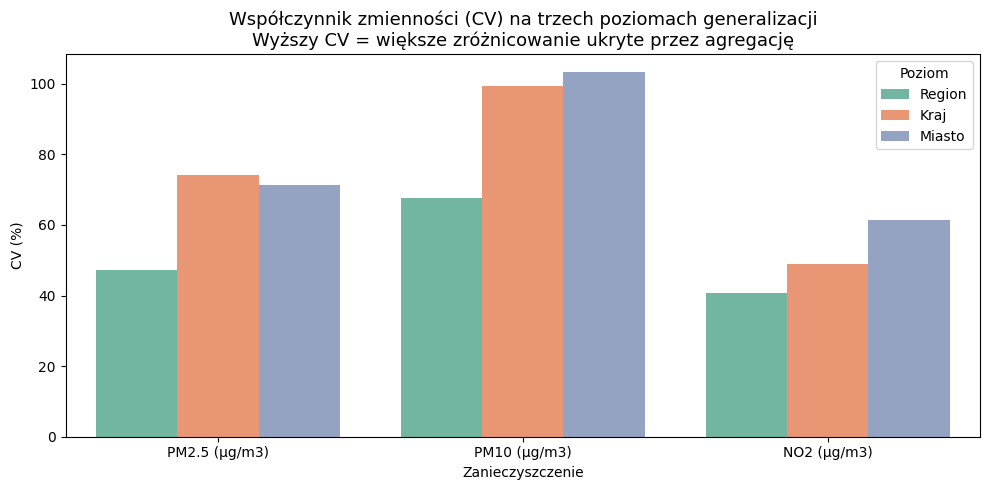

In [38]:
cv_data = []
for level, groupby_col in [('Region', 'WHO Region'), ('Kraj', 'WHO Country Name'), ('Miasto', 'City or Locality')]:
    for poll in pollutants:
        vals = data.groupby(groupby_col)[poll].mean().dropna()
        cv = (vals.std() / vals.mean()) * 100
        cv_data.append({'Poziom': level, 'Zanieczyszczenie': poll, 'CV (%)': round(cv, 1)})

cv_df = pd.DataFrame(cv_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_df, x='Zanieczyszczenie', y='CV (%)', hue='Poziom', palette='Set2')
plt.title('Współczynnik zmienności (CV) na trzech poziomach generalizacji\n'
          'Wyższy CV = większe zróżnicowanie ukryte przez agregację', fontsize=13)
plt.ylabel('CV (%)')
plt.tight_layout()
plt.show()

Im wyższy CV na poziomie miasta vs kraju/regionu, tym bardziej agregacja "wygładza" rzeczywiste zróżnicowanie i ukrywa lokalne zmiany wartości. Regiony odpowiadają za ogromne obszary, często o dużej zmienności a uśredniają dane do pojedynczych wartości, tracąc przy tym wiele informacji. Widać to popraz znacznie niższy poziom CV


**Porównanie poziomu stężenia PM2.5 na różnych poziomach agregacji - przykład Polski”**

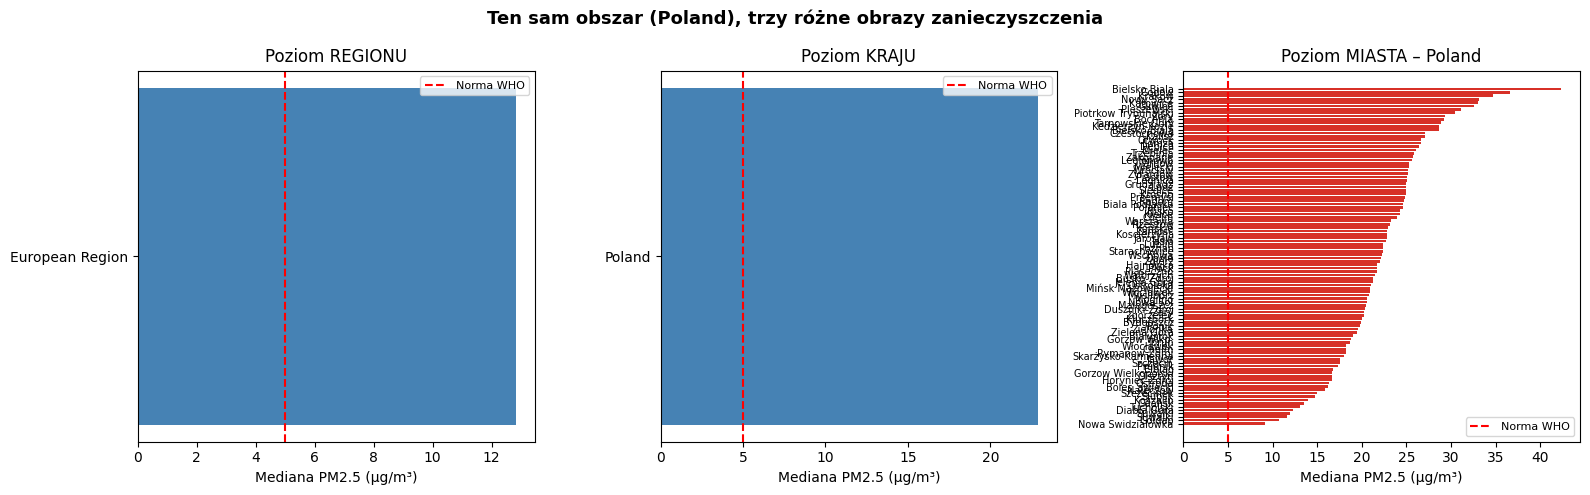

In [39]:
country_example = 'Poland'
region_example  = 'European Region'

val_region  = data[data['WHO Region'] == region_example]['PM2.5 (μg/m3)'].median()
val_country = data[data['WHO Country Name'] == country_example]['PM2.5 (μg/m3)'].median()
cities_vals = (
    data[data['WHO Country Name'] == country_example]
    .groupby('City or Locality')['PM2.5 (μg/m3)'].median()
    .dropna().sort_values()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# region
axes[0].barh([region_example], [val_region], color='steelblue')
axes[0].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[0].set_title('Poziom REGIONU', fontsize=12)
axes[0].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[0].legend(fontsize=8)

# kraj
axes[1].barh([country_example], [val_country], color='steelblue')
axes[1].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[1].set_title('Poziom KRAJU', fontsize=12)
axes[1].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[1].legend(fontsize=8)

# miasta
axes[2].barh(cities_vals.index, cities_vals.values,
             color=['#d73027' if v > WHO_LIMITS['PM2.5 (μg/m3)'] else '#4575b4' for v in cities_vals.values])
axes[2].axvline(WHO_LIMITS['PM2.5 (μg/m3)'], color='red', linestyle='--', label='Norma WHO')
axes[2].set_title(f'Poziom MIASTA – {country_example}', fontsize=12)
axes[2].set_xlabel('Mediana PM2.5 (μg/m³)')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle(f'Ten sam obszar ({country_example}), trzy różne obrazy zanieczyszczenia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Dla tego samego obszaru, czyli Polski, otrzymujemy trzy różne obrazy zanieczyszczenia w zależności od poziomu agregacji danych. Na poziomie regionu europejskiego mediana PM2.5 jest stosunkowo niska, ponieważ obejmuje bardzo wiele krajów i silnie uśrednia wartości. Na poziomie kraju wartość dla Polski jest już wyraźnie wyższa i lepiej opisuje sytuację krajową.

Najwięcej informacji daje poziom miast. Widać, że pomiędzy polskimi miastami występują bardzo duże różnice. Oznacza to, że średnia lub mediana dla kraju nie pokazuje pełnej skali problemu lokalnego.

Wykres dobrze pokazuje, że im wyższy poziom generalizacji, tym bardziej dane są wygładzone. Z kolei poziom miejski ujawnia lokalne różnice, które są niewidoczne na poziomie kraju i regionu.

### Mapa1 
**Interaktywna mapa  karajów - pokazuje MEDIANĘ zanieczyszczenia dla danego roku**

Dropdowny pozwalają wybrać  jakie zanieczyszczenie i rok jest prezentowany. Pozwala to na obserwacje i analizę rozkładu zanieczyszczeń na świecie oraz ich zmiany w czasie. Jednocześnie zastosowanie dropdownów daje też możliwość porównania różnych zanieczyszczeń 


In [40]:
years = sorted(data['Measurement Year'].dropna().unique().astype(int))
poll_labels = {
    'PM2.5 (μg/m3)': 'PM2.5',
    'PM10 (μg/m3)': 'PM10',
    'NO2 (μg/m3)': 'NO2'
}

def plot_country_map(pollutant, year):
    df_plot = (
        data[data['Measurement Year'] == year]
        .groupby(['ISO3', 'WHO Country Name'])[pollutant]
        .median()
        .reset_index()
        .dropna()
    )

    fig = px.choropleth(
        df_plot,
        locations='ISO3',
        color=pollutant,
        hover_name='WHO Country Name',
        color_continuous_scale='Reds',
        projection='natural earth',
        title=f'Mediana {poll_labels[pollutant]} w krajach – {year}'
    )

    fig.update_layout(
        height=550,
        margin=dict(l=0, r=0, t=60, b=0),
        coloraxis_colorbar_title='μg/m³'
    )

    fig.show()

pollutant_dropdown = widgets.Dropdown(
    options=[(poll_labels[p], p) for p in pollutants],
    value=pollutants[0],
    description='Zanieczyszczenie:'
)

year_dropdown = widgets.Dropdown(
    options=years,
    value=years[0],
    description='Rok:'
)

ui = widgets.HBox([pollutant_dropdown, year_dropdown])

out = widgets.interactive_output(
    plot_country_map,
    {
        'pollutant': pollutant_dropdown,
        'year': year_dropdown
    }
)

display(ui, out)

Output()

Po wstępnej analizie widać np. że Mongolia czy Bangladesz dla PM2.5 (o ile w danym roku są dane) niemal zawsze mają jedne z najwyższych zanieczyszczeń.

Dla NO2 dominuje Iran przez cały okres danych.

Dla PM10 niezwykle wysokie wartości ma Egipt (choć dane są tylko dla 3 lat).

Dzieki możliwosći zmiany daty widoczny jest wyrażny spadek wskaźnika PM2.5 w 2019 w niemal całej Azji. Podobna sytuacja jest dla PM10 które stopniowo spada od 2015 roku, przede wszystkim w Chinach w 2018 roku. Wartości jednego zanieczyszczenia też niekonieczne mają związek z innymi np. w Iranie mamy bardzo wysokie NO2, ale stosunkowo niskie PM2.5 i PM10



### Mapa 2

**Przypisanie lokalizacji do miast**

Zdecydowano się pójść na kompromis między dokładnością a pokryciem danych. Mając pewność poprawnego przypisania lokalizacji udało się uzyskać jedynie 55% porycia danych. Dlatego zdecydowano sie zwiększyć pokrycie (82% procent) ryzykując, że pojawią sie pewne błędy w przypisaniu lokalizacji (miasta o tej samej nazwie w różnych krajach). Kilka miast Kuwejtu i Bangladeszu znajduje sie w Europie i Ameryce Południowej, kilka miast wymagało manualnego poprawienia.



In [41]:
import re
import unicodedata

worldcities = pd.read_csv("worldcities.csv")

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = re.sub(r"[^a-z0-9\s\-]", "", x)
    x = re.sub(r"\s+", " ", x)
    return x

city_map_data = data.copy()
city_map_data["city_norm"] = city_map_data["City or Locality"].apply(normalize_text)

manual_map = {
    "new york city": "new york",
    "delhi nct": "delhi",
    "kathmandu valley": "kathmandu",
    "greater london": "london",
    "hong kong sar": "hong kong",
    "mexico d f": "mexico city",
    "saint petersburg": "st petersburg"
}

city_map_data["city_norm"] = city_map_data["city_norm"].replace(manual_map)

worldcities["city_norm"] = worldcities["city"].apply(normalize_text)
worldcities["city_ascii_norm"] = worldcities["city_ascii"].apply(normalize_text)

lookup_1 = worldcities[["iso3", "city_norm", "lat", "lng", "population"]].copy()
lookup_2 = worldcities[["iso3", "city_ascii_norm", "lat", "lng", "population"]].copy()
lookup_2 = lookup_2.rename(columns={"city_ascii_norm": "city_norm"})

city_lookup = pd.concat([lookup_1, lookup_2], ignore_index=True)

city_lookup = (
    city_lookup
    .dropna(subset=["iso3", "city_norm", "lat", "lng"])
    .sort_values(["iso3", "city_norm", "population"], ascending=[True, True, False])
    .drop_duplicates(subset=["iso3", "city_norm"])
)

df1 = city_map_data.merge(
    city_lookup[["iso3", "city_norm", "lat", "lng"]],
    left_on=["ISO3", "city_norm"],
    right_on=["iso3", "city_norm"],
    how="left"
)

df2 = city_map_data.merge(
    city_lookup[["city_norm", "lat", "lng"]],
    on="city_norm",
    how="left"
)

df1["lat"] = df1["lat"].fillna(df2["lat"])
df1["lng"] = df1["lng"].fillna(df2["lng"])

city_map_data = df1.copy()

matched = city_map_data["lat"].notna().sum()
all_rows = len(city_map_data)

print(f"Liczba wszystkich rekordów: {all_rows}")
print(f"Liczba rekordów z dopasowanymi współrzędnymi: {matched}")
print(f"Odsetek dopasowanych rekordów: {matched / all_rows * 100:.2f}%")

city_map_data = city_map_data[city_map_data["lat"].notna() & city_map_data["lng"].notna()].copy()

city_year_map = (
    city_map_data
    .groupby(
        ["WHO Region", "WHO Country Name", "City or Locality", "Measurement Year", "lat", "lng"],
        as_index=False
    )[pollutants]
    .median()
)
total_cities = data["City or Locality"].nunique()
mapped_cities = city_year_map["City or Locality"].nunique()
coverage_pct = mapped_cities / total_cities * 100

print("\nPokrycie miast")
print(f"Liczba wszystkich miast w WHO: {total_cities}")
print(f"Liczba miast na mapie: {mapped_cities}")
print(f"Liczba niedopasowanych miast: {total_cities - mapped_cities}")
print(f"Odsetek pokrycia miast: {coverage_pct:.2f}%")

Liczba wszystkich rekordów: 32191
Liczba rekordów z dopasowanymi współrzędnymi: 26525
Odsetek dopasowanych rekordów: 82.40%

Pokrycie miast
Liczba wszystkich miast w WHO: 6874
Liczba miast na mapie: 5687
Liczba niedopasowanych miast: 1187
Odsetek pokrycia miast: 82.73%


**Mapa punktowa miast - pokazuje stężenie zanieczyszczeń w poszczególnych miastach**

Jest możliwość filtrowania po zanieczyszczeniu, roku i regionie, co pozwala na bardziej szczegółową analizę. Możemy znajdować miasta o bardzo wysokim zanieczyszczeniu, które się wyróżniają, a w danych dla kraju/regionu jest to niewidoczne.

Bez generalizacji możemy znajdować też regiony z innym zanieczyszczeniem wewnątrz poszczególnych krajów (choć często granice państw równiez są widoczne).
Doskonałym przykładem są Włochy (np PM2.5 2015), gdzie doskonale widoczna jest Nizina Padańska, która ma znacznie gęstesze pokrycie czujnikami oraz 
odcina sie wyższymi wartościami od południowej części kraju, jednocześnie z północy jest odcięta Alpami od znacznie niższych wartości w reszcie Europy. 

Mapa pozwala także ocenic jak rozmieszczone są dane - widać ogromne różnice pokrycia danych w zależności od regionu czy kraju. Wiele krajów jest znacznie mniej reprezentatywnych niż inne ponieważ mają np tylko czujnik w jednym mieście (ilość miast z danym dla kraju w komórce niżej). Przykładem może być wspomniany wcześniej Egipt, gdzie mamy zaledwie 2 miasta z czujnikami i to one odpowiadają za tak ogromne wartości PM10

Przy tej mapie jest także możliwość filtracji po regionach.



In [42]:
from IPython.display import display

poll_labels = {
    'PM2.5 (μg/m3)': 'PM2.5',
    'PM10 (μg/m3)': 'PM10',
    'NO2 (μg/m3)': 'NO2'
}

years_city = sorted(city_year_map["Measurement Year"].dropna().unique().astype(int))
regions_city = ["Wszystkie"] + sorted(city_year_map["WHO Region"].dropna().unique().tolist())

def plot_city_map(pollutant, year, region):
    df_plot = city_year_map[city_year_map["Measurement Year"] == year].copy()

    if region != "Wszystkie":
        df_plot = df_plot[df_plot["WHO Region"] == region].copy()

    df_plot = df_plot.dropna(subset=[pollutant])

    if df_plot.empty:
        print("Brak danych dla wybranej kombinacji filtrów.")
        return

    fig = px.scatter_geo(
        df_plot,
        lat="lat",
        lon="lng",
        color=pollutant,
        hover_name="City or Locality",
        hover_data={
            "WHO Country Name": True,
            "WHO Region": True,
            "Measurement Year": True,
            "PM2.5 (μg/m3)": ":.2f",
            "PM10 (μg/m3)": ":.2f",
            "NO2 (μg/m3)": ":.2f",
            "lat": False,
            "lng": False
        },
        color_continuous_scale="Reds",
        projection="natural earth",
        title=f"Stężenie {poll_labels[pollutant]} w miastach – {year}, region: {region}",
        opacity=0.8
    )

    fig.update_traces(
        marker=dict(
            size=6,
            line=dict(width=0.5, color="white")
        )
    )

    fig.update_layout(
        height=650,
        margin=dict(l=0, r=0, t=60, b=0),
        coloraxis_colorbar_title="μg/m³",
        geo=dict(showcountries=True, countrycolor="black")
    )

    fig.show()


pollutant_dropdown_city = widgets.Dropdown(
    options=[(poll_labels[p], p) for p in pollutants],
    value=pollutants[0],
    description='Zanieczyszczenie:'
)

year_dropdown_city = widgets.Dropdown(
    options=years_city,
    value=years_city[0],
    description='Rok:'
)

region_dropdown_city = widgets.Dropdown(
    options=regions_city,
    value="Wszystkie",
    description='Region:'
)

ui_city = widgets.HBox([pollutant_dropdown_city, year_dropdown_city, region_dropdown_city])

out_city = widgets.interactive_output(
    plot_city_map,
    {
        'pollutant': pollutant_dropdown_city,
        'year': year_dropdown_city,
        'region': region_dropdown_city
    }
)

display(ui_city, out_city)

Output()

Kontrola pokrycia mapy dla wybranego kraju

In [43]:
import ipywidgets as widgets
from IPython.display import display

countries = sorted(data["WHO Country Name"].dropna().unique().tolist())

def check_country_coverage(country):
    who_cities = (
        data.loc[data["WHO Country Name"] == country, "City or Locality"]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    mapped_cities = (
        city_map_data.loc[city_map_data["WHO Country Name"] == country, "City or Locality"]
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    total_count = len(who_cities)
    mapped_count = len(mapped_cities)
    missing_count = total_count - mapped_count
    coverage_pct = (mapped_count / total_count * 100) if total_count > 0 else 0

    print(f"Kraj: {country}")
    print(f"Liczba miast w danych WHO: {total_count}")
    print(f"Liczba miast pokazanych na mapie: {mapped_count}")
    print(f"Liczba miast niepokazanych na mapie: {missing_count}")
    print(f"Odsetek pokrycia: {coverage_pct:.2f}%")

    missing_cities = sorted(set(who_cities) - set(mapped_cities))

    if missing_cities:
        print("\nPrzykładowe miasta brakujące na mapie:")
        for city in missing_cities[:20]:
            print("-", city)
        if len(missing_cities) > 20:
            print(f"... oraz {len(missing_cities) - 20} kolejnych.")

country_dropdown = widgets.Dropdown(
    options=countries,
    description="Kraj:",
    layout=widgets.Layout(width="500px")
)

out_country = widgets.interactive_output(
    check_country_coverage,
    {"country": country_dropdown}
)

display(country_dropdown, out_country)

Dropdown(description='Kraj:', layout=Layout(width='500px'), options=('Afghanistan', 'Albania', 'Algeria', 'And…

Output()

ZALETY ANALIZY NA MAPACH

- pozwala zobaczyć rozmieszczenie przestrzenne zanieczyszczeń,
- ułatwia identyfikację obszarów problemowych,
- daje bardziej intuicyjne zrozumienie danych,
- umożliwia porównanie regionów, krajów i miast w kontekście geograficznym,
- interaktywność pozwala analizować zmiany w czasie,
  
OGRANICZENIA ANALIZY NA MAPACH
- różna liczba miast w krajach,
- dopasowanie miast (geokodowanie) może być niedokładne,
- różnice w skali kolorów mogą utrudniać porównania między latami,

**Podsumowanie głównych związków przyczynowo-skutkowych między różnymi zmiennymi, zauważone na podstawie przeprowadzonych analiz**

Najsilniejsza zależność występuje pomiędzy PM2.5 a PM10, co potwierdzają zarówno wykresy rozrzutu, jak i wartości współczynnika korelacji Pearsona. Wskazuje to, że oba typy pyłów mają wspólne źródła emisji, takie jak transport, przemysł czy spalanie paliw.

W przypadku NO2 zależność z pozostałymi zmiennymi jest wyraźnie słabsza, szczególnie na poziomie miast. Może to sugerować, że NO2 pochodzi z innych źródeł.

Analiza na różnych poziomach generalizacji pokazuje, że interpretacja zależności zależy od skali danych. Na poziomie regionów zależności są bardziej uśrednione i stabilne, natomiast na poziomie miast widoczna jest większa zmienność oraz lokalne ekstremalne wartości. Oznacza to, że agregacja danych może maskować rzeczywiste różnice i prowadzić do uproszczonych wniosków.

Z przeprowadzonych analiz wynika również, że poziom zanieczyszczenia powietrza różni się między regionami świata. Najwyższe wartości obserwowane są w regionach Azji oraz Eastern Mediterranean, co może być związane z intensywną urbanizacją, dużą liczbą ludności oraz rozwiniętym przemysłem. Z kolei niższe wartości w Europie i regionie Ameryk mogą wynikać z bardziej restrykcyjnych regulacji środowiskowych oraz lepiej rozwiniętych systemów monitoringu.

Jednocześnie należy podkreślić, że wszystkie te wnioski silnie zależą od poziomu agregacji danych. Przykładowo, dla regionu South East Asia zależność między PM2.5 a NO2 jest umiarkowana, jednak po analizie na poziomie poszczególnych krajów okazuje się, że w Indiach jest ona relatywnie wysoka (~0.61), podczas gdy w Bangladeszu i Tajlandii jest bardzo niska (ok. 0.03). Pokazuje to, że analiza wyłącznie na poziomie regionów może prowadzić do uśrednionego obrazu rzeczywistości i pominięcia istotnych różnic między krajami, a tym samym do błędnych wniosków.

**Jakie potencjalne zastosowania ma ten rodzaj danych w uczeniu maszynowym?**

Dane dotyczące zanieczyszczeń powietrza mogą stanowić podstawę do budowy modeli uczenia maszynowego, których celem jest prognozowanie poziomu zanieczyszczeń lub klasyfikacja obszarów pod względem jakości powietrza. W analizie można wykorzystać zmienne takie jak w analizowanym datasecie i dołączyć dodatkowe jak np. warunki atmosferyczne. Należy jednak zauważyć, że zbiór danych posiada ograniczenia, takie jak duża liczba braków (związane z tym, że np. w niektórych miejscach pomiary były zaczęte później, wcześniej niż w innych miejscach) oraz brak dodatkowych zmiennych opisujących przyczyny zanieczyszczeń (np. warunki pogodowe). 

Należałoby się również ograniczyc do prognozowania na danym poziomie, czyli dla danego regionu, czy dla danych państw. Podejście na poziomie regionów ma swoje zalety, takie jak większa kompletność danych oraz bardziej uogólniony obraz zjawiska, jednak prowadzi do utraty szczegółowych informacji. Z kolei modele na poziomie krajów stanowią kompromis pomiędzy szczegółowością, a jakością danych – pozwalają uchwycić różnice między państwami.

W związku z tym wybór poziomu agregacji w modelach uczenia maszynowego powinien być uzależniony od celu analizy - dla prognoz globalnych lepsze będą regiony, natomiast dla bardziej szczegółowych analiz - poziom krajów. 

Dane te mogą być również wykorzystane do wykrywania anomalii, czyli nietypowych obserwacji znacząco odbiegających od pozostałych. Szczególnie sensowne jest przeprowadzenie takiej analizy na poziomie miast, gdzie widoczna jest największa zmienność danych. Anomalie mogą oznaczać zarówno rzeczywiste epizody bardzo wysokiego zanieczyszczenia (np. smog), jak i potencjalne błędy pomiarowe. Warto podkreślić, że wykrywanie anomalii jest bardziej uzasadnione na poziomie miast niż regionów czy krajów, ponieważ agregacja danych na wyższych poziomach może ukrywać ekstremalne wartości i prowadzić do ich wygładzenia.

**Declaration**

During the preparation of this work, the authors used Claude and ChatGPT for debugging code only. After using these tools, the authors carefully reviewed and verified all results and take full responsibility for the correctness and integrity of the code and the published work.